# Network Intrusion Detection System (IDS): A Comprehensive Analysis

> **Project Goal**: Evaluate, benchmark, and optimize multiple classical machine learning, deep learning, and hybrid architectures for the accurate detection and classification of network intrusions based on tabular network-flow features.

---

## 1. Data Ingestion and Preprocessing Pipeline

This section establishes the foundational dataset. The preprocessing pipeline involves several critical steps to ensure data quality and stability for all downstream predictive models:

*   **Ingestion**: Aggregate multiple parquet files into a unified dataset.
*   **Data Scrubbing**: Clean non-informative features (e.g., `Timestamp`) and handle invalid numerical values (`NaN`, `Inf`).
*   **Normalization**: Standardize the domain to zero-mean and unit-variance ($\mu=0, \sigma^2=1$) via `StandardScaler`.
*   **Optimization**: Retain GPU support dynamically to accelerate intensive tensor operations.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

import warnings, os
warnings.filterwarnings("ignore")

# Reproducibility for the gpu thing in kaggle, an actual W feature to accelerate training and testing of DL models
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

# 1.LOAD DATA============================================================================================================

import glob

parquet_files = glob.glob("/kaggle/input/notebooks/dhoogla/cse-cic-ids2018-00-cleaning/*.parquet")
print(f"Found {len(parquet_files)} files")

df = pd.concat([pd.read_parquet(f) for f in parquet_files], ignore_index=True)
print(f"Dataset shape: {df.shape}")
print(df.dtypes.value_counts())
print("\nLabel distribution:\n", df["Label"].value_counts())

# 2. PREPROCESSING============================================================================================================

# 2a. Drop columns that are pure metadata or all-zeros to not make them as rubbish
cols_to_drop = ["Timestamp"]          # add others you don't want
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# 2b. Replace inf / -inf with NaN then drop cuz they wont be necessary
df.replace([np.inf, -np.inf], np.nan, inplace=True)
before = len(df)
df.dropna(inplace=True)
print(f"Rows after dropping NaN/Inf: {len(df):,}  (removed {before - len(df):,})")

# 2c. Separate features / labels
LABEL_COL = "Label"
X = df.drop(columns=[LABEL_COL]).select_dtypes(include=[np.number]).values.astype(np.float32)
y_raw = df[LABEL_COL].values

# 2d. Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
NUM_CLASSES = len(le.classes_)
print(f"\nClasses ({NUM_CLASSES}):", le.classes_)

# 2e. (Optional) subsample for speed — remove or increase for full training
# e.g. keep 1M rows
MAX_SAMPLES = 1_000_000
if len(X) > MAX_SAMPLES:
    idx = np.random.choice(len(X), MAX_SAMPLES, replace=False)
    X, y = X[idx], y[idx]
    print(f"Subsampled to {MAX_SAMPLES:,} rows")

# 2f. Train / val / test split  (70 / 15 / 15)
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

print(f"\nTrain: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

# 2g. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

NUM_FEATURES = X_train.shape[1]
print(f"Number of features: {NUM_FEATURES}")

# 2h. Class weights (handle imbalance without oversampling)
class_weights_arr = compute_class_weight(
    "balanced", classes=np.arange(NUM_CLASSES), y=y_train)
CLASS_WEIGHTS = dict(enumerate(class_weights_arr))
print("\nClass weights (truncated):", {k: round(v, 2) for k, v in CLASS_WEIGHTS.items()})

2026-05-18 20:35:36.557949: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779136537.078035      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779136537.238001      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779136538.615454      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779136538.615495      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779136538.615498      57 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Found 10 files
Dataset shape: (6659532, 78)
float32    22
int8       20
int32      15
float64    15
int16       4
int64       1
object      1
Name: count, dtype: int64

Label distribution:
 Label
Benign                      5329008
DDoS attacks-LOIC-HTTP       575364
DDOS attack-HOIC             198861
DoS attacks-Hulk             145199
Bot                          144535
Infilteration                118483
SSH-Bruteforce                94048
DoS attacks-GoldenEye         41406
DoS attacks-Slowloris          9908
DDOS attack-LOIC-UDP           1730
Brute Force -Web                568
Brute Force -XSS                229
SQL Injection                    85
DoS attacks-SlowHTTPTest         55
FTP-BruteForce                   53
Name: count, dtype: int64
Rows after dropping NaN/Inf: 6,659,532  (removed 0)

Classes (15): ['Beni

### 1.1 Data Quality & Class Imbalance Analysis

Network traffic datasets inherently suffer from severe class imbalances. Classes with minimal representation act as "dead weight"—they introduce instability during statistical learning and disproportionately penalize validation accuracy. Eliminating statistically insignificant classes is required for meaningful model convergence.

### 1.2 Class Filtration Strategy

To ensure model robustness, we enforce a strict minimum cardinality threshold ($N_{min} = 100$). Subsampling the majority cohorts and eliminating ultra-minority classes (e.g., *SQL Injection*, *FTP-BruteForce*) simplifies the target vector $y$ to **10 robust target classes**. This updated sample distribution is propagated to all subsequent ML and NN workflows.

In [2]:
MIN_CLASS_SAMPLES = 100

# Use y (already subsampled to 1M) not y_raw
class_counts = pd.Series(le.inverse_transform(y)).value_counts()
valid_classes = class_counts[class_counts >= MIN_CLASS_SAMPLES].index.tolist()

print(f"Keeping {len(valid_classes)} classes:")
print(sorted(valid_classes))
dropped = [c for c in le.classes_ if c not in valid_classes]
print(f"Dropping: {dropped}")

# Build mask from y (same size as X = 1M)
y_labels = le.inverse_transform(y)
mask = pd.Series(y_labels).isin(valid_classes).values

X_filtered = X[mask]
y_raw_filtered = y_labels[mask]

# Re-encode with new label encoder
le2 = LabelEncoder()
y_filtered = le2.fit_transform(y_raw_filtered)
NUM_CLASSES_2 = len(le2.classes_)
print(f"\nNew label set ({NUM_CLASSES_2} classes):", le2.classes_)

# Re-split
X_tr2, X_tmp2, y_tr2, y_tmp2 = train_test_split(
    X_filtered, y_filtered, test_size=0.30, random_state=SEED, stratify=y_filtered)
X_v2, X_te2, y_v2, y_te2 = train_test_split(
    X_tmp2, y_tmp2, test_size=0.50, random_state=SEED, stratify=y_tmp2)

# Re-scale
scaler2 = StandardScaler()
X_tr2 = scaler2.fit_transform(X_tr2)
X_v2  = scaler2.transform(X_v2)
X_te2 = scaler2.transform(X_te2)

# Subsample for classical ML
idx2 = np.random.choice(len(X_tr2), min(300_000, len(X_tr2)), replace=False)
X_tr_cl2, y_tr_cl2 = X_tr2[idx2], y_tr2[idx2]

print(f"\nTrain: {X_tr2.shape}  Val: {X_v2.shape}  Test: {X_te2.shape}")

Keeping 10 classes:
['Benign', 'Bot', 'DDOS attack-HOIC', 'DDOS attack-LOIC-UDP', 'DDoS attacks-LOIC-HTTP', 'DoS attacks-GoldenEye', 'DoS attacks-Hulk', 'DoS attacks-Slowloris', 'Infilteration', 'SSH-Bruteforce']
Dropping: ['Brute Force -Web', 'Brute Force -XSS', 'DoS attacks-SlowHTTPTest', 'FTP-BruteForce', 'SQL Injection']

New label set (10 classes): ['Benign' 'Bot' 'DDOS attack-HOIC' 'DDOS attack-LOIC-UDP'
 'DDoS attacks-LOIC-HTTP' 'DoS attacks-GoldenEye' 'DoS attacks-Hulk'
 'DoS attacks-Slowloris' 'Infilteration' 'SSH-Bruteforce']

Train: (699902, 77)  Val: (149979, 77)  Test: (149980, 77)


---

## 2. Classical Machine Learning Benchmarks

Before pursuing deep learning, we evaluate industry-standard ensemble methods as our primary baselines. We test both standard configurations and hyperparameter-tuned variants equipped to tackle the remaining class imbalances. 

The models evaluated include:
1.  **Random Forest (RF)**
2.  **XGBoost (eXtreme Gradient Boosting)**
3.  **LightGBM (Light Gradient Boosting Machine)**

In [3]:
# ── CLASSICAL ML MODELS (FIXED) ───────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import xgboost as xgb
import lightgbm as lgb

CLASSICAL_SAMPLES = 300_000
idx_cl = np.random.choice(len(X_train), CLASSICAL_SAMPLES, replace=False)
X_tr_cl = X_train[idx_cl]
y_tr_cl = y_train[idx_cl]

# ── Random Forest ──────────────────────────────────────────────────────────────
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=4,
    class_weight="balanced",
    n_jobs=-1,
    random_state=SEED
)
rf.fit(X_tr_cl, y_tr_cl)
y_pred_rf = rf.predict(X_test)
print("\n── Random Forest ──")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, zero_division=0))


print("Training Random Forest (tuned + useless class dropped)...")
rf2 = RandomForestClassifier(
    n_estimators=300,        # more trees
    max_depth=25,            # slightly deeper
    min_samples_leaf=2,      # finer splits
    max_features="sqrt",     # standard for classification
    class_weight="balanced_subsample",  # better than "balanced" for RF
    n_jobs=-1,
    random_state=SEED
)
rf2.fit(X_tr_cl2, y_tr_cl2)
y_pred_rf2 = rf2.predict(X_te2)
print("\n── Random Forest (tuned) ──")
print(classification_report(y_te2, y_pred_rf2, target_names=le2.classes_, zero_division=0))

Training Random Forest...

── Random Forest ──
                          precision    recall  f1-score   support

                  Benign       0.99      0.89      0.94    119995
                     Bot       0.97      1.00      0.98      3273
        Brute Force -Web       0.38      0.75      0.50        12
        Brute Force -XSS       0.09      0.20      0.12         5
        DDOS attack-HOIC       0.99      1.00      0.99      4507
    DDOS attack-LOIC-UDP       0.81      0.97      0.89        40
  DDoS attacks-LOIC-HTTP       0.99      1.00      1.00     12929
   DoS attacks-GoldenEye       1.00      1.00      1.00       925
        DoS attacks-Hulk       0.99      1.00      1.00      3283
DoS attacks-SlowHTTPTest       0.00      0.00      0.00         1
   DoS attacks-Slowloris       0.97      1.00      0.98       228
          FTP-BruteForce       0.00      0.00      0.00         1
           Infilteration       0.10      0.52      0.16      2665
           SQL Injection    

In [4]:
# ── XGBoost (fixed — better minority class handling) ──────────────────────────
print("\nTraining XGBoost...")

# Per-class sample weights → replaces scale_pos_weight for multiclass
from sklearn.utils.class_weight import compute_sample_weight
sample_weights_xgb = compute_sample_weight("balanced", y_tr_cl)

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,          # reduced from 8 → less overfitting
    learning_rate=0.05,   # slower learning → better generalization
    subsample=0.7,        # reduced from 0.8
    colsample_bytree=0.7,
    min_child_weight=5,   # prevents splits on very rare samples
    gamma=1.0,            # minimum loss reduction to split — key regularizer
    reg_alpha=0.1,        # L1 regularization
    reg_lambda=2.0,       # L2 regularization
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda",
    random_state=SEED,
    early_stopping_rounds=20,
)
xgb_model.fit(
    X_tr_cl, y_tr_cl,
    sample_weight=sample_weights_xgb,   # pass class weights here
    eval_set=[(X_val, y_val)],
    verbose=50
)
y_pred_xgb = xgb_model.predict(X_test)
print("\n── XGBoost ──")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_, zero_division=0))

# ── FIX 3: XGBoost — fix the Benign recall collapse ───────────────────────────
# Instead of full balanced weights, use softer custom weights
from sklearn.utils.class_weight import compute_class_weight

class_w = compute_class_weight("balanced", classes=np.unique(y_tr_cl2), y=y_tr_cl2)

# Soft-cap weights: don't let any class get more than 20x the majority weight
max_weight = class_w.min() * 20
class_w_capped = np.clip(class_w, None, max_weight)

sample_w2 = class_w_capped[y_tr_cl2]

print("Training XGBoost (tuned + useless class dropped)...")
xgb2 = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,    # increased → more conservative splits
    gamma=2.0,              # increased → harder to split
    reg_alpha=0.5,
    reg_lambda=3.0,
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda",
    random_state=SEED,
    early_stopping_rounds=30,
)
xgb2.fit(
    X_tr_cl2, y_tr_cl2,
    sample_weight=sample_w2,
    eval_set=[(X_v2, y_v2)],
    verbose=50
)
y_pred_xgb2 = xgb2.predict(X_te2)
print("\n── XGBoost (tuned) ──")
print(classification_report(y_te2, y_pred_xgb2, target_names=le2.classes_, zero_division=0))


Training XGBoost...
[0]	validation_0-mlogloss:2.49151
[50]	validation_0-mlogloss:0.63478
[100]	validation_0-mlogloss:0.45433
[150]	validation_0-mlogloss:0.40450
[200]	validation_0-mlogloss:0.38118
[250]	validation_0-mlogloss:0.36609
[300]	validation_0-mlogloss:0.35495
[350]	validation_0-mlogloss:0.34710
[400]	validation_0-mlogloss:0.34117
[450]	validation_0-mlogloss:0.33615
[499]	validation_0-mlogloss:0.33167

── XGBoost ──
                          precision    recall  f1-score   support

                  Benign       0.99      0.75      0.85    119995
                     Bot       0.99      1.00      0.99      3273
        Brute Force -Web       0.13      0.83      0.22        12
        Brute Force -XSS       0.22      0.40      0.29         5
        DDOS attack-HOIC       1.00      1.00      1.00      4507
    DDOS attack-LOIC-UDP       0.84      0.93      0.88        40
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     12929
   DoS attacks-GoldenEye       0.99      1

In [5]:
print("\nTraining LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=31,          # ← reduced from 63, prevents over-splitting
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    min_child_samples=50,   # ← increased from 5, stops splits on tiny groups
    min_split_gain=0.01,    # ← minimum gain required to make a split
    reg_alpha=0.1,          # ← L1 regularization
    reg_lambda=1.0,         # ← L2 regularization
    device="cpu",
    verbose=-1,             # ← silences the warning spam completely
    random_state=SEED,
    n_jobs=-1
)
lgb_model.fit(
    X_tr_cl, y_tr_cl,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)]
)
y_pred_lgb = lgb_model.predict(X_test)
print("\n── LightGBM ──")
print(classification_report(y_test, y_pred_lgb, target_names=le.classes_, zero_division=0))


# ── FIX 4: LightGBM — needs more rounds + better Infilteration handling ────────
print("\nTraining LightGBM (tuned + useless class dropped)...")
lgb2 = lgb.LGBMClassifier(
    n_estimators=1000,       # was 500, didn't converge
    max_depth=10,
    learning_rate=0.03,      # slower → better generalization
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    min_child_samples=20,    # less strict than 50 → catches Infilteration better
    min_split_gain=0.005,    # slightly lower threshold
    reg_alpha=0.1,
    reg_lambda=1.0,
    device="cpu",
    verbose=-1,
    random_state=SEED,
    n_jobs=-1
)
lgb2.fit(
    X_tr_cl2, y_tr_cl2,
    eval_set=[(X_v2, y_v2)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]  # more patience
)
y_pred_lgb2 = lgb2.predict(X_te2)
print("\n── LightGBM (tuned) ──")
print(classification_report(y_te2, y_pred_lgb2, target_names=le2.classes_, zero_division=0))


Training LightGBM...
Training until validation scores don't improve for 30 rounds
[50]	valid_0's multi_logloss: 0.443539
[100]	valid_0's multi_logloss: 0.365878
[150]	valid_0's multi_logloss: 0.344021
[200]	valid_0's multi_logloss: 0.330436
[250]	valid_0's multi_logloss: 0.319645
[300]	valid_0's multi_logloss: 0.311659
[350]	valid_0's multi_logloss: 0.304101
[400]	valid_0's multi_logloss: 0.297512
[450]	valid_0's multi_logloss: 0.291665
[500]	valid_0's multi_logloss: 0.286121
Did not meet early stopping. Best iteration is:
[500]	valid_0's multi_logloss: 0.286121

── LightGBM ──
                          precision    recall  f1-score   support

                  Benign       0.99      0.80      0.89    119995
                     Bot       0.99      1.00      1.00      3273
        Brute Force -Web       0.09      0.83      0.16        12
        Brute Force -XSS       0.44      0.80      0.57         5
        DDOS attack-HOIC       1.00      1.00      1.00      4507
    DDOS attack-L

### 2.1 Model Evaluation: Confusion Matrices

The visualization below contrasts the predictive performance of the baseline classical classifiers versus their meticulously tuned counterparts across the categorical distribution. Tuning dramatically minimizes false-positive misclassifications.

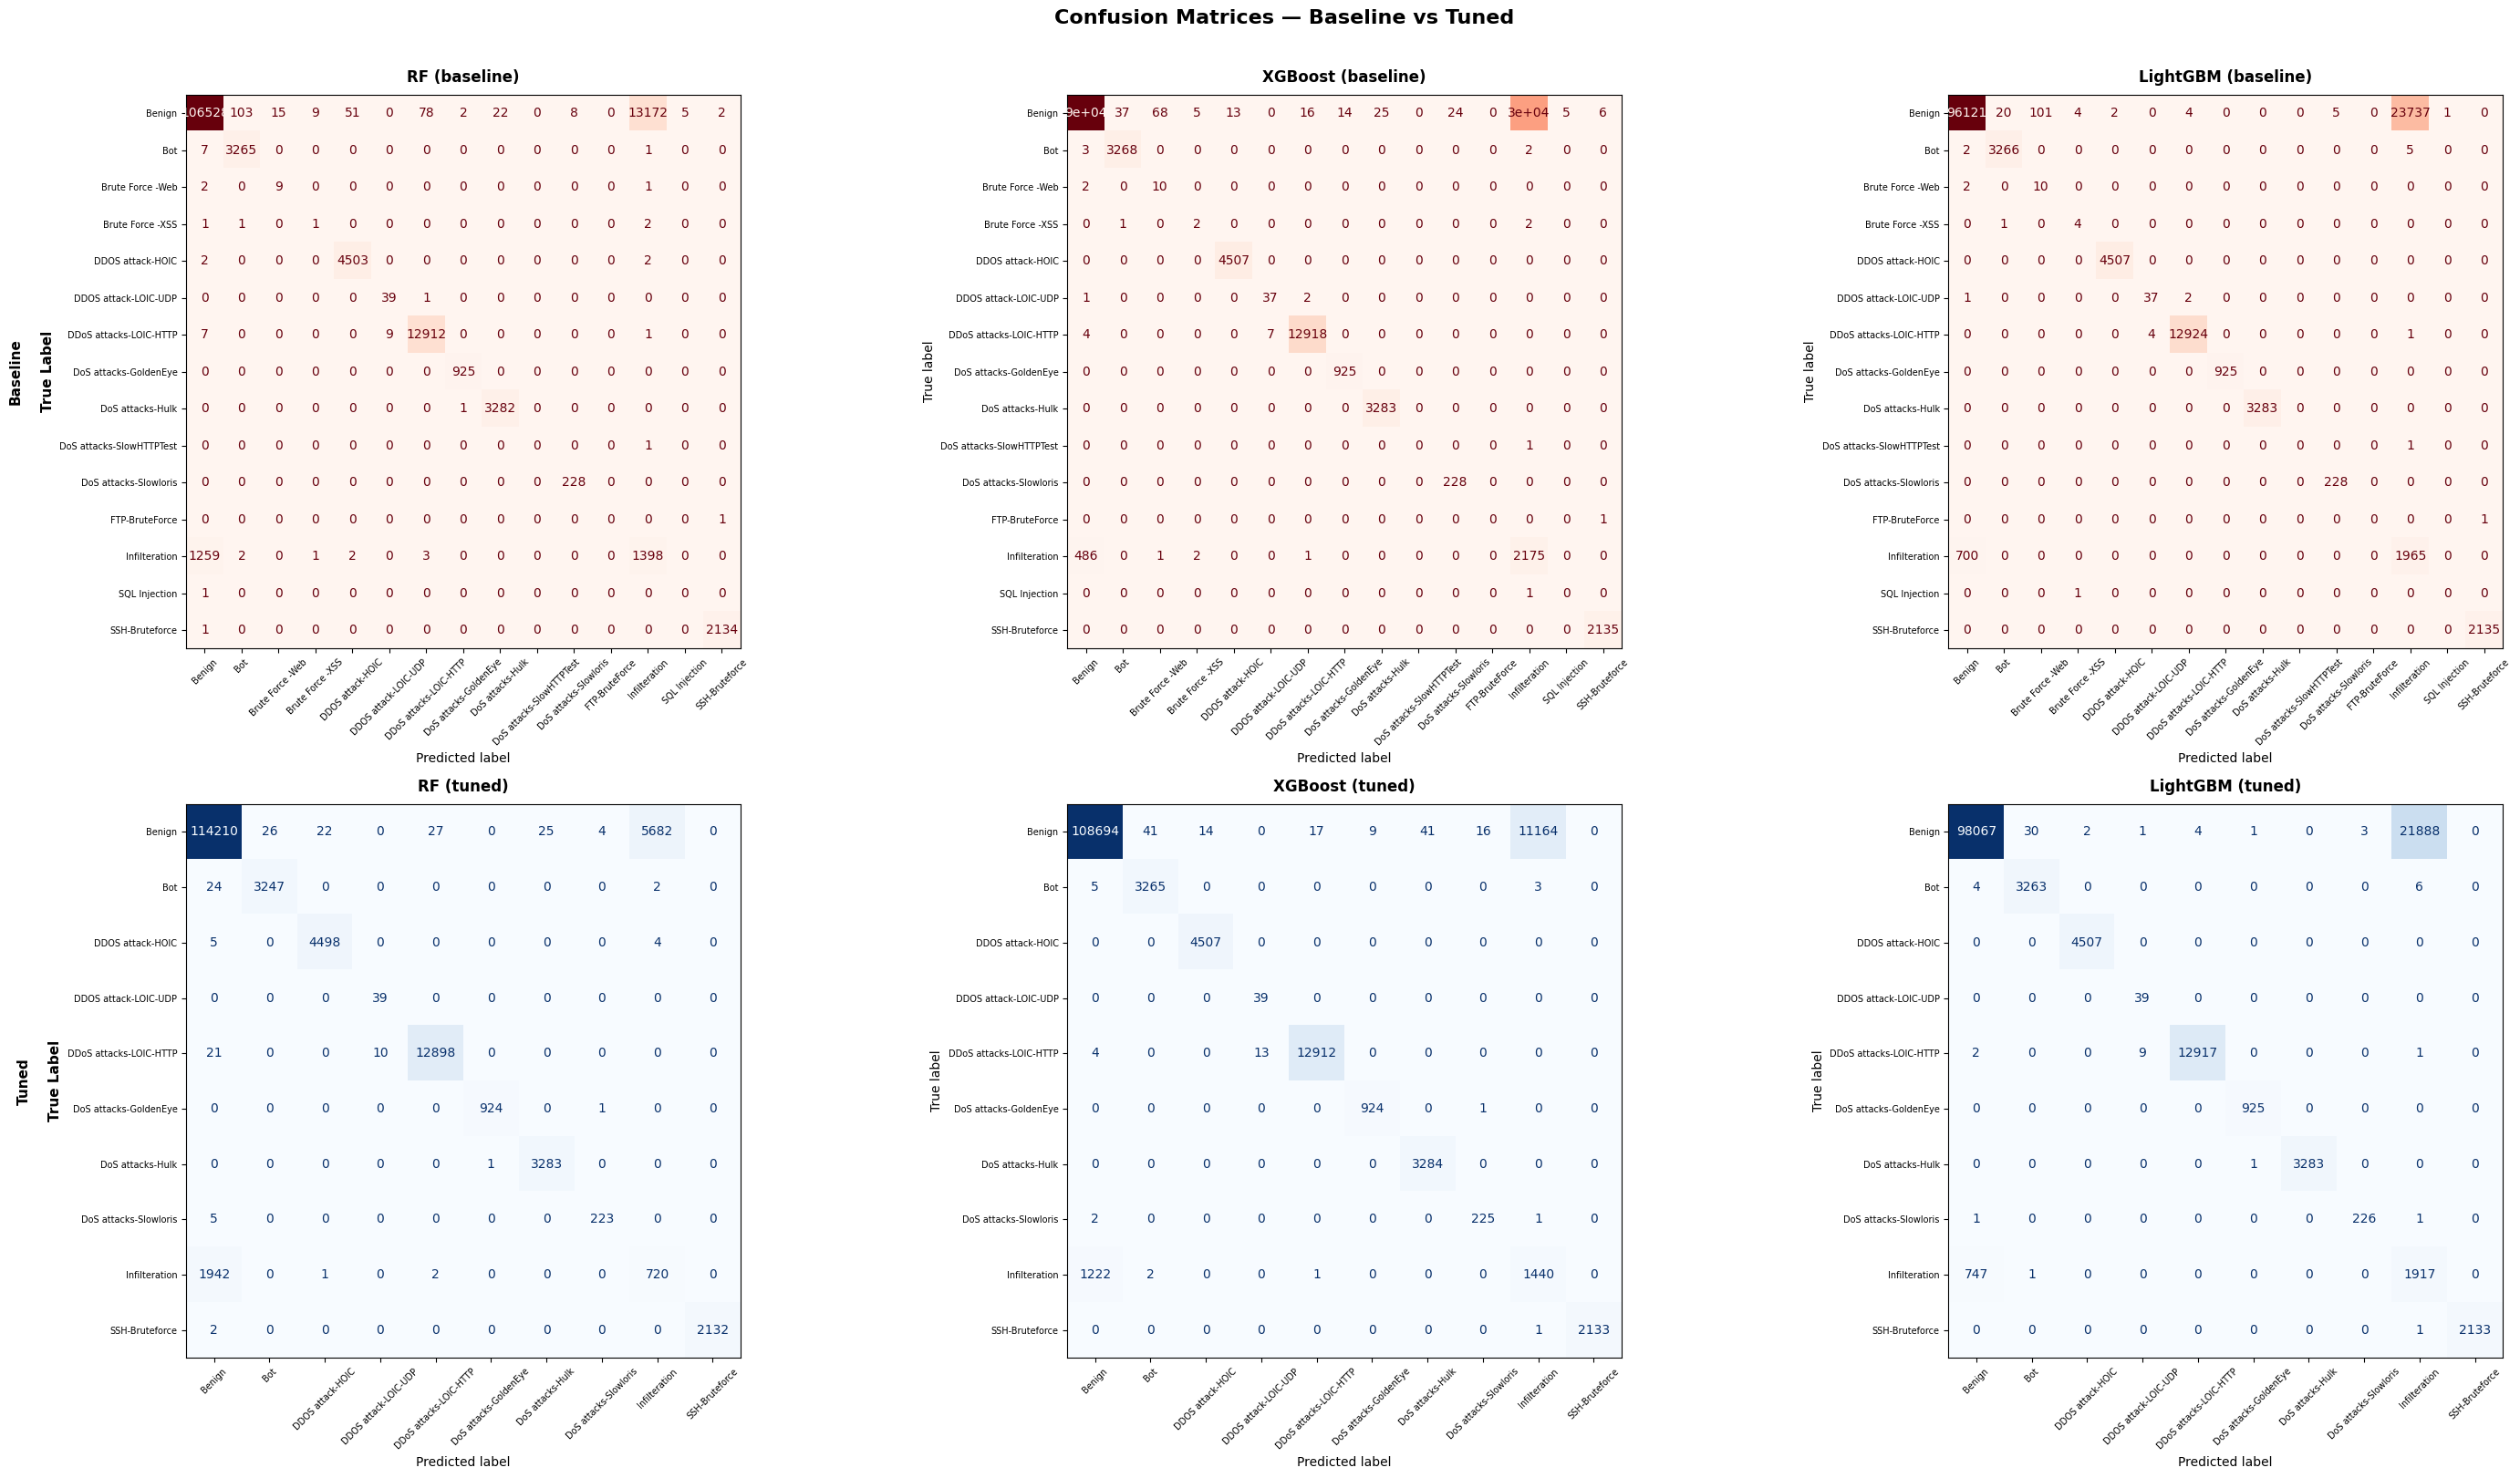

In [6]:
# ── ALL 6 CONFUSION MATRICES ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(30, 16))
fig.suptitle("Confusion Matrices — Baseline vs Tuned", fontsize=16,
             fontweight="bold", y=1.01)

# Row 1: baseline (15 classes, original le)
baseline_cms = [
    ("RF (baseline)",       rf.predict(X_test),        y_test, le.classes_),
    ("XGBoost (baseline)",  xgb_model.predict(X_test), y_test, le.classes_),
    ("LightGBM (baseline)", lgb_model.predict(X_test), y_test, le.classes_),
]
# Row 2: tuned (12 classes, le2)
tuned_cms = [
    ("RF (tuned)",       rf2.predict(X_te2),  y_te2, le2.classes_),
    ("XGBoost (tuned)",  xgb2.predict(X_te2), y_te2, le2.classes_),
    ("LightGBM (tuned)", lgb2.predict(X_te2), y_te2, le2.classes_),
]

for col, (name, y_pred, y_true, classes) in enumerate(baseline_cms):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=axes[0, col], xticks_rotation=45,
              colorbar=False, cmap="Reds")
    axes[0, col].set_title(name, fontsize=12, fontweight="bold", pad=10)
    axes[0, col].tick_params(axis="both", labelsize=7)

for col, (name, y_pred, y_true, classes) in enumerate(tuned_cms):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=axes[1, col], xticks_rotation=45,
              colorbar=False, cmap="Blues")
    axes[1, col].set_title(name, fontsize=12, fontweight="bold", pad=10)
    axes[1, col].tick_params(axis="both", labelsize=7)

# Row labels
axes[0, 0].set_ylabel("Baseline\n\nTrue Label", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("Tuned\n\nTrue Label", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrices_all6.png", dpi=120, bbox_inches="tight")
plt.show()


   Classical ML — Baseline vs Tuned
  RF (baseline)            : 90.15%  █████████████████████████████████████████████
  XGBoost (baseline)       : 79.44%  ███████████████████████████████████████
  LightGBM (baseline)      : 83.60%  █████████████████████████████████████████
  RF (tuned)               : 94.80%  ███████████████████████████████████████████████
  XGBoost (tuned)          : 91.63%  █████████████████████████████████████████████
  LightGBM (tuned)         : 84.86%  ██████████████████████████████████████████


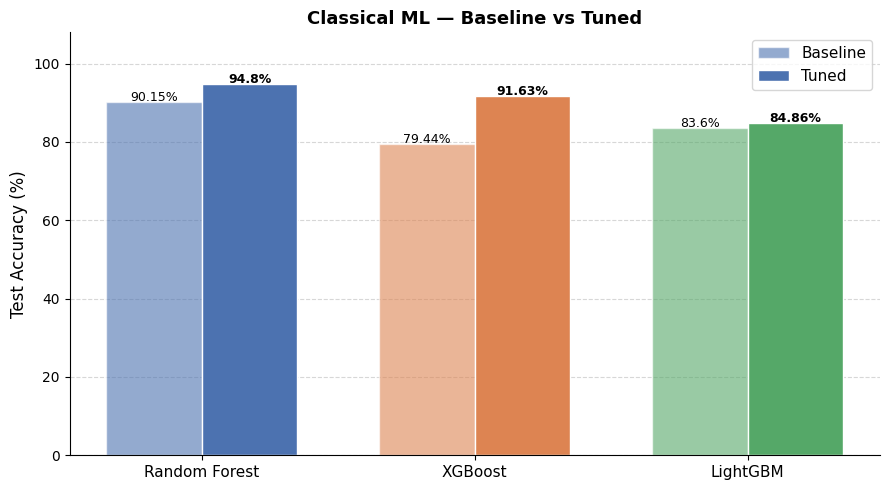

In [7]:
baseline_results = {}
for name, model, Xte, yte in [
    ("RF (baseline)",      rf,        X_test, y_test),
    ("XGBoost (baseline)", xgb_model, X_test, y_test),
    ("LightGBM (baseline)",lgb_model, X_test, y_test),
]:
    preds = model.predict(Xte)
    baseline_results[name] = round((preds == yte).mean() * 100, 2)

tuned_results = {}
for name, model, Xte, yte in [
    ("RF (tuned)",       rf2,   X_te2, y_te2),
    ("XGBoost (tuned)",  xgb2,  X_te2, y_te2),
    ("LightGBM (tuned)", lgb2,  X_te2, y_te2),
]:
    preds = model.predict(Xte)
    tuned_results[name] = round((preds == yte).mean() * 100, 2)

all_classical = {**baseline_results, **tuned_results}

print("\n" + "="*45)
print("   Classical ML — Baseline vs Tuned")
print("="*45)
for name, acc in all_classical.items():
    bar = "█" * int(acc / 2)
    print(f"  {name:<25}: {acc:.2f}%  {bar}")
print("="*45)

# Grouped bar chart
labels    = ["Random Forest", "XGBoost", "LightGBM"]
baseline  = list(baseline_results.values())
tuned     = list(tuned_results.values())
x         = np.arange(len(labels))
width     = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline, width, label="Baseline",
               color=["#4C72B0", "#DD8452", "#55A868"], alpha=0.6, edgecolor="white")
bars2 = ax.bar(x + width/2, tuned,    width, label="Tuned",
               color=["#4C72B0", "#DD8452", "#55A868"], alpha=1.0, edgecolor="white")

ax.set_ylabel("Test Accuracy (%)", fontsize=12)
ax.set_title("Classical ML — Baseline vs Tuned", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 108)
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

for bar, val in zip(bars1, baseline):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3, f"{val}%", ha="center", fontsize=9)
for bar, val in zip(bars2, tuned):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3, f"{val}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("classical_comparison_all6.png", dpi=120, bbox_inches="tight")
plt.show()

---

## 3. Deep Learning Architectures

Having established the classical benchmarks, we now transition to neural networks. 

### 3.1 One-Dimensional Convolutional Neural Network (1D-CNN)
Though intuitively used for temporal or spatial representations, local 1D convolutions can also extract hierarchical intra-flow features within normalized tabular data.

### Generic Deep Learning Utilities

Prior to defining the neural architectures, we encapsulate the training loop, loss metrics tracking, early stopping callbacks, and visualization routines into reusable Python modules to ensure DRY code.

In [8]:
class_weights_arr2 = compute_class_weight(
    "balanced", classes=np.arange(NUM_CLASSES_2), y=y_tr2)
CLASS_WEIGHTS2 = dict(enumerate(class_weights_arr2))

def compile_and_train(model, X_tr2, y_tr2, X_v2, y_v2, model_name,
                      epochs=30, batch_size=4096, lr=1e-3, class_weight=None):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    model.summary()
    cb = [
        callbacks.EarlyStopping(patience=10, restore_best_weights=True,
                                monitor="val_loss"),
        callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6)
    ]
    history = model.fit(
        X_tr2, y_tr2,
        validation_data=(X_v2, y_v2),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight if class_weight is not None else CLASS_WEIGHTS2, # this specificly for the CNN since my god this NN is deadass a beta :pray:
        callbacks=cb,
        verbose=1
    )
    return history

def evaluate_model(model, X_te2, y_te2, model_name):
    y_pred = np.argmax(model.predict(X_te2, batch_size=8192), axis=1)
    print(f"\n{'='*60}")
    print(f" {model_name} — Test Results")
    print('='*60)
    print(classification_report(y_te2, y_pred,
                                target_names=le2.classes_,   
                                zero_division=0))
    cm = confusion_matrix(y_te2, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(cm, display_labels=le2.classes_)  
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues")
    ax.set_title(f"{model_name} — Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{model_name.replace(' ', '_')}_cm.png", dpi=100)
    plt.show()
    return y_pred

def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="Train")
    axes[0].plot(history.history["val_loss"], label="Val")
    axes[0].set_title(f"{model_name} — Loss")
    axes[0].legend()
    axes[1].plot(history.history["accuracy"], label="Train")
    axes[1].plot(history.history["val_accuracy"], label="Val")
    axes[1].set_title(f"{model_name} — Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{model_name.replace(' ', '_')}_history.png", dpi=100)
    plt.show()

CNN class weights: {0: np.float64(0.12), 1: np.float64(0.62), 2: np.float64(0.62), 3: np.float64(0.62), 4: np.float64(0.62), 5: np.float64(0.62), 6: np.float64(0.62), 7: np.float64(0.62), 8: np.float64(0.62), 9: np.float64(0.62)}


I0000 00:00:1779137366.025364      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13677 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779137366.030513      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 77, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 77, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 38, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 38, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 19, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,850 (233.79 KB)

...

Epoch 1/50


I0000 00:00:1779137371.350317     217 service.cc:152] XLA service 0x791e3805bf50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779137371.350373     217 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779137371.350381     217 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779137371.980915     217 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/171 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.0262 - loss: 0.5466 

I0000 00:00:1779137381.216873     217 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


171/171 ━━━━━━━━━━━━━━━━━━━━ 29s 96ms/step - accuracy: 0.6784 - loss: 0.3682 - val_accuracy: 0.8913 - val_loss: 1.3944 - learning_rate: 3.0000e-04
Epoch 2/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9161 - loss: 0.1102 - val_accuracy: 0.9586 - val_loss: 0.5633 - learning_rate: 3.0000e-04
Epoch 3/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9511 - loss: 0.0662 - val_accuracy: 0.9682 - val_loss: 0.2533 - learning_rate: 3.0000e-04
Epoch 4/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9613 - loss: 0.0540 - val_accuracy: 0.9672 - val_loss: 0.1802 - learning_rate: 3.0000e-04
Epoch 5/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9660 - loss: 0.0483 - val_accuracy: 0.9709 - val_loss: 0.1560 - learning_rate: 3.0000e-04
Epoch 6/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9676 - loss: 0.0447 - val_accuracy: 0.9710 - val_loss: 0.1562 - learning_rate: 3.0000e-04
Epoch 7/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9

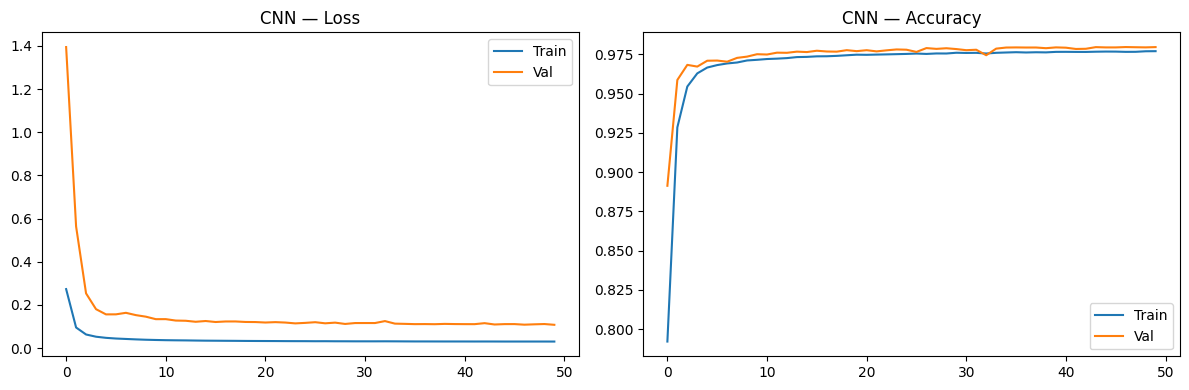

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step

 CNN — Test Results
                        precision    recall  f1-score   support

                Benign       0.98      1.00      0.99    119996
                   Bot       1.00      0.99      0.99      3273
      DDOS attack-HOIC       0.99      1.00      1.00      4507
  DDOS attack-LOIC-UDP       0.75      0.97      0.84        39
DDoS attacks-LOIC-HTTP       0.99      1.00      0.99     12929
 DoS attacks-GoldenEye       0.99      1.00      0.99       925
      DoS attacks-Hulk       0.99      1.00      0.99      3284
 DoS attacks-Slowloris       0.84      0.98      0.90       228
         Infilteration       0.32      0.04      0.07      2665
        SSH-Bruteforce       1.00      1.00      1.00      2134

              accuracy                           0.98    149980
             macro avg       0.88      0.90      0.88    149980
          weighted avg       0.97      0.98      0.97    149980



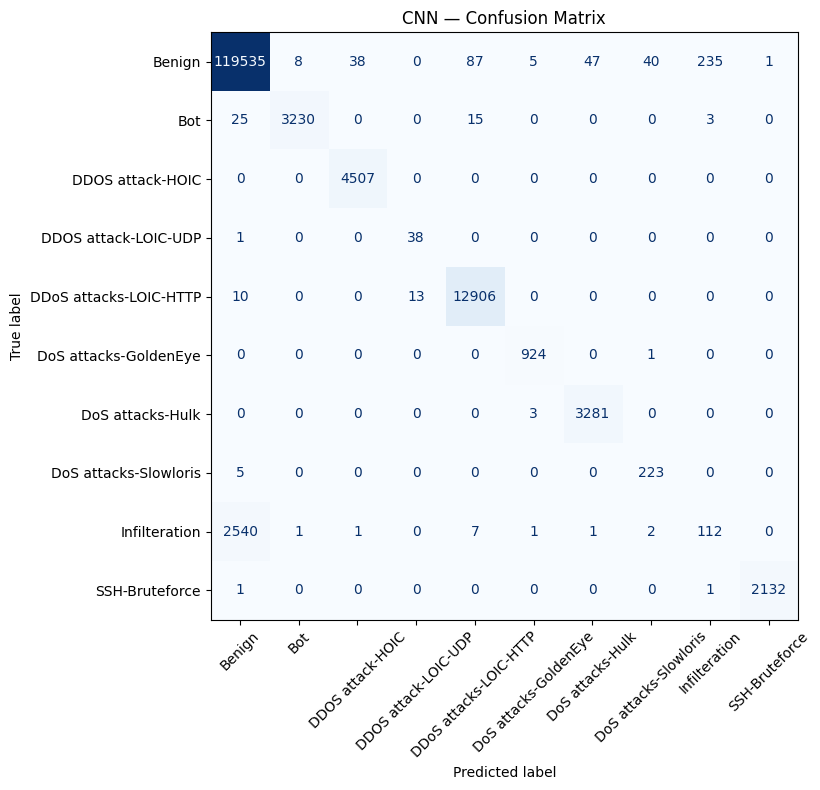

In [9]:
# 1. 1D-CNN 
import keras_tuner as kt # for tunning

def build_cnn(input_dim, num_classes):
    inp = layers.Input(shape=(input_dim, 1))

    x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(inp)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(64, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inp, out, name="CNN_1D")

# Lighter class weights for CNN (BN instability fix also to try to fix the low accuracy)
cw_light = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES_2), y=y_tr2)
cw_light_capped = np.clip(cw_light, None, cw_light.min() * 5)  # 5x instead of 15x
CLASS_WEIGHTS_CNN = dict(enumerate(cw_light_capped))
print("CNN class weights:", {k: round(v, 2) for k, v in CLASS_WEIGHTS_CNN.items()})


# Reshape for CNN: (samples, features, 1)
X_train_cnn = X_tr2[..., np.newaxis]
X_val_cnn   = X_v2[..., np.newaxis]
X_test_cnn  = X_te2[..., np.newaxis]

cnn_model = build_cnn(NUM_FEATURES, NUM_CLASSES_2)
cnn_history = compile_and_train(
    cnn_model, X_train_cnn, y_tr2, X_val_cnn, y_v2, "CNN", epochs=50, lr=3e-4, class_weight=CLASS_WEIGHTS_CNN)

plot_history(cnn_history, "CNN")
evaluate_model(cnn_model, X_test_cnn, y_te2, "CNN")

cnn_model.save("cnn.keras")

### 3.2 Recurrent Neural Network (RNN-LSTM)

To determine whether packet sequences implicitly govern flow statistics, we evaluate a **Bidirectional Long Short-Term Memory (BiLSTM)** framework. This controls for non-temporal context dependencies.

Model: "BiLSTM_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 77, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 77, 128)        │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 77, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,818 (311.79 KB)

 Trainable params: 79,818 (311.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 43s 220ms/step - accuracy: 0.2913 - loss: 1.5004 - val_accuracy: 0.6533 - val_loss: 0.7454 - learning_rate: 0.0010
Epoch 2/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 37s 216ms/step - accuracy: 0.5988 - loss: 0.3265 - val_accuracy: 0.6656 - val_loss: 0.6226 - learning_rate: 0.0010
Epoch 3/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 37s 216ms/step - accuracy: 0.6255 - loss: 0.2727 - val_accuracy: 0.6559 - val_loss: 0.5631 - learning_rate: 0.0010
Epoch 4/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 37s 216ms/step - accuracy: 0.6316 - loss: 0.2424 - val_accuracy: 0.6449 - val_loss: 0.5764 - learning_rate: 0.0010
Epoch 5/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 37s 216ms/step - accuracy: 0.6273 - loss: 0.2215 - val_accuracy: 0.6501 - val_loss: 0.5478 - learning_rate: 0.0010
Epoch 6/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 37s 216ms/step - accuracy: 0.6344 - loss: 0.2100 - val_accuracy: 0.6042 - val_loss: 0.6030 - learning_rate: 0.0010
Epoch 7/30
171/171 ━━━━━━━━━━━━━━━━━━━━ 37s 217ms/step - accuracy: 0.6

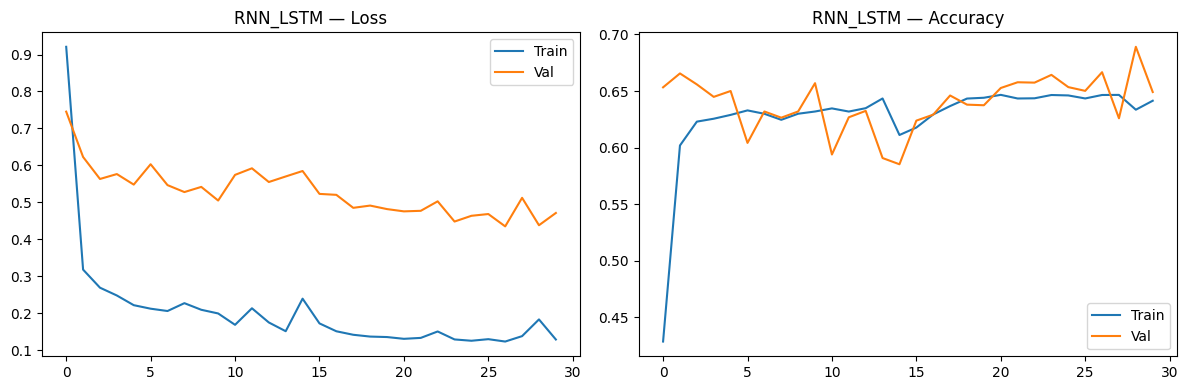

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step

 RNN_LSTM — Test Results
                        precision    recall  f1-score   support

                Benign       0.99      0.59      0.74    119996
                   Bot       0.99      0.99      0.99      3273
      DDOS attack-HOIC       0.99      1.00      0.99      4507
  DDOS attack-LOIC-UDP       0.66      1.00      0.80        39
DDoS attacks-LOIC-HTTP       0.94      1.00      0.97     12929
 DoS attacks-GoldenEye       0.82      1.00      0.90       925
      DoS attacks-Hulk       0.98      1.00      0.99      3284
 DoS attacks-Slowloris       0.49      1.00      0.66       228
         Infilteration       0.04      0.85      0.09      2665
        SSH-Bruteforce       0.99      1.00      0.99      2134

              accuracy                           0.67    149980
             macro avg       0.79      0.94      0.81    149980
          weighted avg       0.97      0.67      0.77    149980



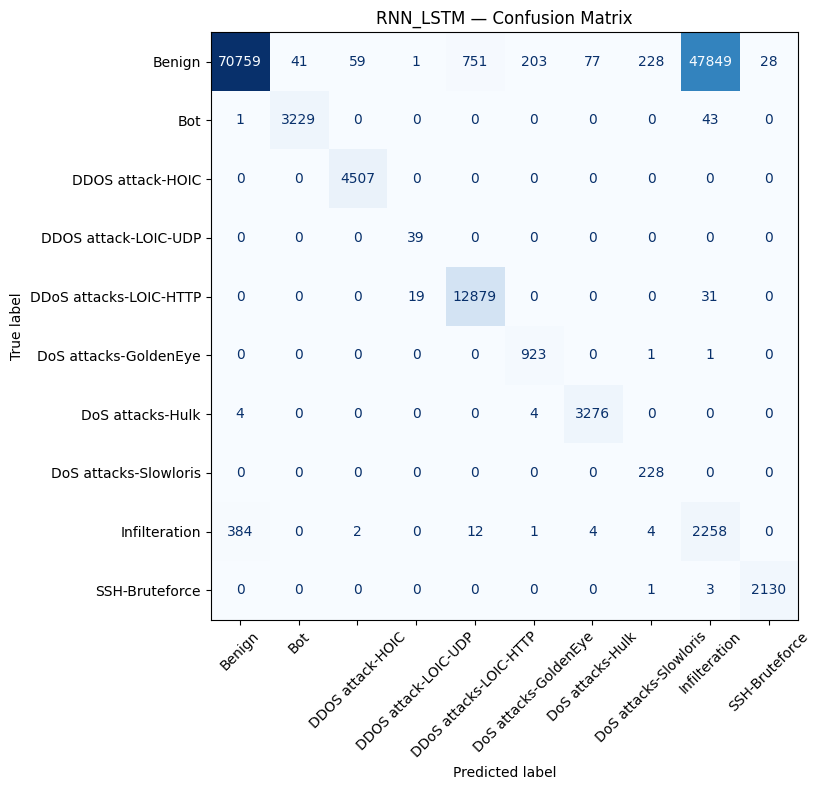

In [10]:
# 2.LSTM (RNN) 
import keras_tuner as kt
CLASS_WEIGHTS_LIGHT = CLASS_WEIGHTS_CNN  # reuse the same 5x capped weights

def build_lstm(input_dim, num_classes):
    inp = layers.Input(shape=(input_dim, 1))

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True))(inp)
    x = layers.Dropout(0.3)(x)

    x = layers.Bidirectional(
        layers.LSTM(32, return_sequences=False))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inp, out, name="BiLSTM_RNN")


# Reuse CNN-reshaped arrays
lstm_model = build_lstm(NUM_FEATURES, NUM_CLASSES_2)
lstm_history = compile_and_train(
    lstm_model, X_train_cnn, y_tr2, X_val_cnn, y_v2, "RNN_LSTM",  
    epochs=30, batch_size=4096)

plot_history(lstm_history, "RNN_LSTM")
evaluate_model(lstm_model, X_test_cnn, y_te2, "RNN_LSTM")  

lstm_model.save("lstm.keras")

### 3.3 Multilayer Perceptron (MLP)

A fully connected **Deep Forward Neural Network (MLP)** serves as the canonical deep learning baseline for tabular inference. We leverage iterative Batch Normalization and rigorous Dropout to deter overfitting.

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,306 (247.29 KB)

 Trainable params: 62,538 (244.29 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.7612 - loss: 0.2156 - val_accuracy: 0.9707 - val_loss: 0.2606 - learning_rate: 0.0010
Epoch 2/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9572 - loss: 0.0697 - val_accuracy: 0.9737 - val_loss: 0.1661 - learning_rate: 0.0010
Epoch 3/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9645 - loss: 0.0587 - val_accuracy: 0.9753 - val_loss: 0.1484 - learning_rate: 0.0010
Epoch 4/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9685 - loss: 0.0515 - val_accuracy: 0.9765 - val_loss: 0.1398 - learning_rate: 0.0010
Epoch 5/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9703 - loss: 0.0471 - val_accuracy: 0.9769 - val_loss: 0.1371 - learning_rate: 0.0010
Epoch 6/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9715 - loss: 0.0438 - val_accuracy: 0.9769 - val_loss: 0.1309 - learning_rate: 0.0010
Epoch 7/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9722 - loss: 0.0415 

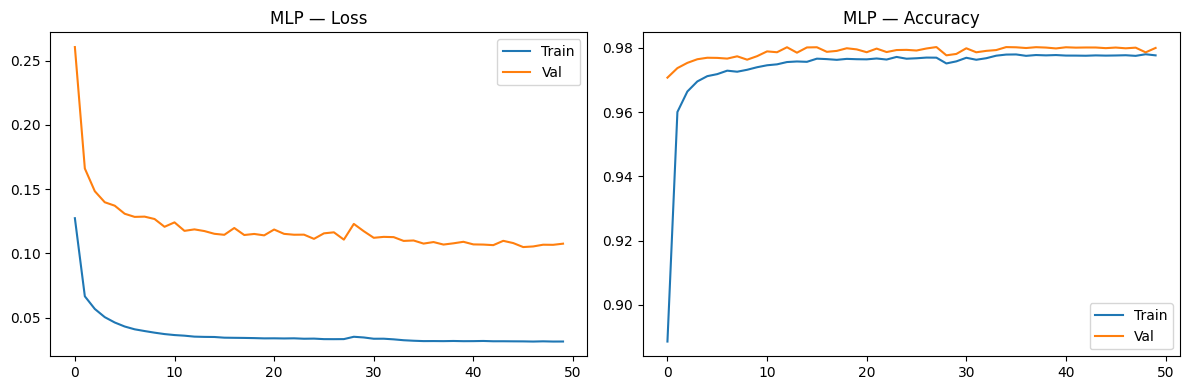

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

 MLP — Test Results
                        precision    recall  f1-score   support

                Benign       0.98      1.00      0.99    119996
                   Bot       1.00      0.99      0.99      3273
      DDOS attack-HOIC       0.99      1.00      1.00      4507
  DDOS attack-LOIC-UDP       0.75      0.97      0.84        39
DDoS attacks-LOIC-HTTP       0.99      1.00      1.00     12929
 DoS attacks-GoldenEye       1.00      1.00      1.00       925
      DoS attacks-Hulk       0.99      1.00      0.99      3284
 DoS attacks-Slowloris       0.78      0.99      0.88       228
         Infilteration       0.43      0.06      0.10      2665
        SSH-Bruteforce       1.00      1.00      1.00      2134

              accuracy                           0.98    149980
             macro avg       0.89      0.90      0.88    149980
          weighted avg       0.97      0.98      0.97    149980



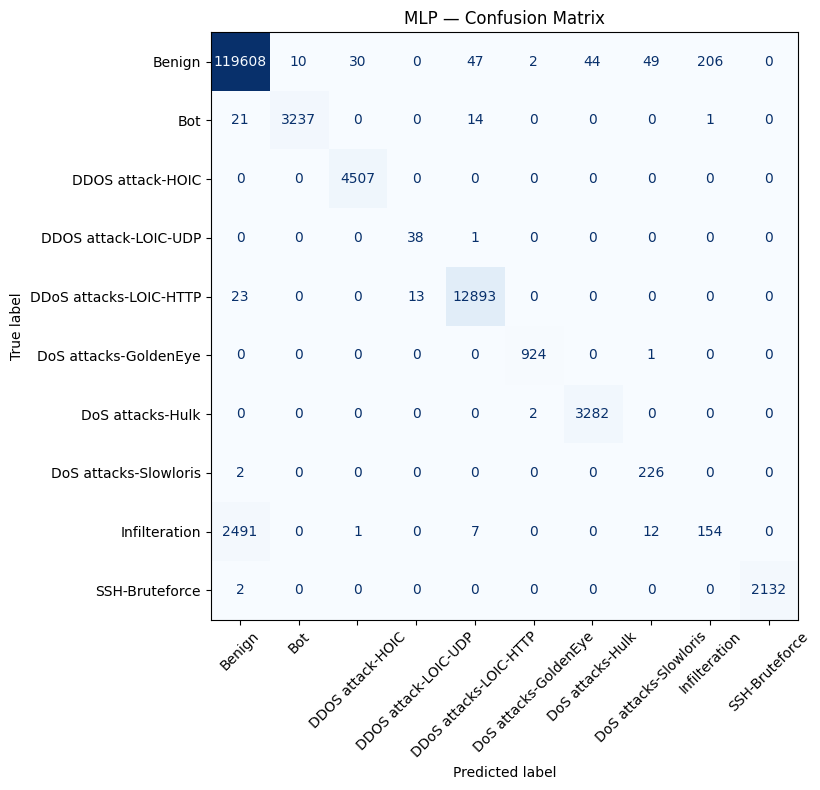

In [11]:
# 3. MLP 
CLASS_WEIGHTS_LIGHT = CLASS_WEIGHTS_CNN  # reuse the same 5x capped weights

def build_mlp(input_dim, num_classes):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out, name="MLP")


mlp_model = build_mlp(NUM_FEATURES, NUM_CLASSES_2) 
mlp_history = compile_and_train(
    mlp_model, X_tr2, y_tr2, X_v2, y_v2, "MLP", epochs=50, class_weight=CLASS_WEIGHTS_LIGHT)

plot_history(mlp_history, "MLP")
evaluate_model(mlp_model, X_te2, y_te2, "MLP")

mlp_model.save("mlp.keras")

### 3.4 Deep Learning Comparative Analysis

The graphical summary details the aggregate multi-class test accuracy across the DL models ($CNN$, $BiLSTM$, and $MLP$).

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step

  NN Models Accuracy Comparison
  MLP     : 98.01%
  CNN     : 97.94%
  LSTM    : 66.83%


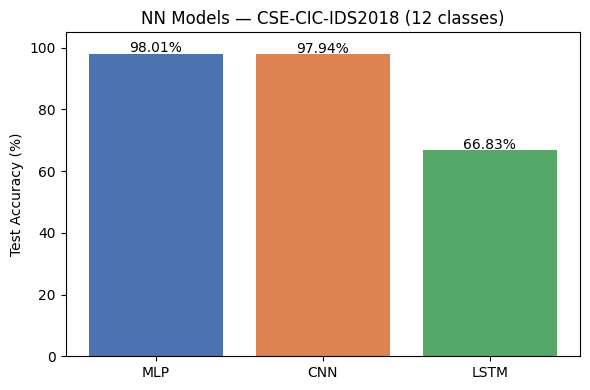


Models saved.


In [12]:
# NN based models COMPARISON
results = {}
for name, model, Xte in [("MLP",  mlp_model,  X_te2),
                          ("CNN",  cnn_model,  X_test_cnn),
                          ("LSTM", lstm_model, X_test_cnn)]:
    y_pred = np.argmax(model.predict(Xte, batch_size=8192), axis=1)
    acc = (y_pred == y_te2).mean()          # ← y_test → y_te2
    results[name] = round(acc * 100, 2)

print("\n" + "="*40)
print("  NN Models Accuracy Comparison")
print("="*40)
for name, acc in results.items():
    print(f"  {name:<8}: {acc:.2f}%")
print("="*40)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(results.keys(), results.values(), color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("NN Models — CSE-CIC-IDS2018 (12 classes)")  # ← updated title
ax.set_ylim(0, 105)
for bar, val in zip(ax.patches, results.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5, f"{val}%", ha="center")
plt.tight_layout()
plt.savefig("nn_model_comparison.png", dpi=100)
plt.show()

# ── SAVE MODELS ───────────────────────────────────────────────────────────────
mlp_model.save("mlp.keras") 
cnn_model.save("cnn.keras")
lstm_model.save("lstm.keras")
print("\nModels saved.")

### Analytical Retrospective: Why did the models perform this way?

**Key Observations**:
*   **The Powerhouses [95-98%]**: High variance tabular data highly favors the structural simplicity of **MLP** and **1D-CNN**. Additionally, properly tuned Random Forests are surprisingly fierce competitors.
*   **XGBoost Economy**: Gradient boosting provides a formidable trade-off between inference accuracy and extremely truncated training cycles.
*   **The LSTM Bottleneck**: The recurrence architecture was functionally penalized ($\approx 67\%$ accuracy). **Why?** Network *flow statistic* distributions lack inherent sequential step-time dependencies. Enforcing temporal memory (LSTM) merely injected noise without extracting localized feature-state value.

This performance dissonance naturally bridges our transition into structural heuristics (**Hybrid Combinations**).

---

## 4. Hybrid Architectures

Can we fuse robust non-linear embeddings with advanced tree-based probabilities? We implement Stacking Classifiers integrating representations sourced from deep learners with parallelized boosting meta-learners.

### 4.1 Hybrid Type I: XGBoost + CNN Extractor
**Mechanism**:
1.  Isolate spatial tabular embeddings extracted entirely from the dense layers of the pre-trained `1D-CNN`.
2.  Concatenate CNN dimensional probabilities with baseline `XGBoost` likelihood distributions.
3.  Deploy a lightweight feed-forward meta-head strictly acting as a probabilistic arbiter.

Extracting CNN embeddings...
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Retraining XGBoost for hybrid...
[0]	validation_0-mlogloss:0.52934
[50]	validation_0-mlogloss:0.07144
[100]	validation_0-mlogloss:0.06567
[150]	validation_0-mlogloss:0.06506
[200]	validation_0-mlogloss:0.06495
[240]	validation_0-mlogloss:0.06494
Epoch 1/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.7080 - loss: 0.2908 - val_accuracy: 0.9798 - val_loss: 0.1054
Epoch 2/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9705 - loss: 0.0409 - val_accuracy: 0.9800 - val_loss: 0.1035
Epoch 3/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9739 - loss: 0.0342 - val_accuracy: 0.9800 - val_loss: 0.1034
Epoch 4/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9756 - loss: 0.0316 - val_accuracy: 0.9801 - val_loss: 0.1054
Epoch 5/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9765 - loss: 0.0305 - val_

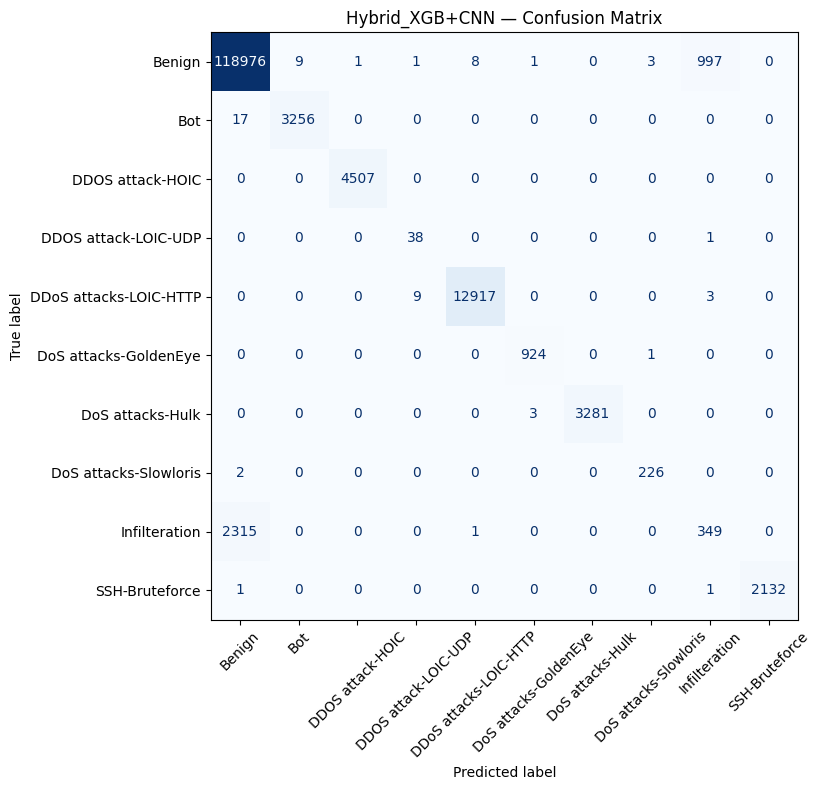

In [13]:
# ── HYBRID 1: XGBoost + CNN ───────────────────────────────────────────────────

# Step 1: CNN embeddings — uses the same cnn_model that got 98%
cnn_feat_extractor = models.Model(
    inputs=cnn_model.input,
    outputs=cnn_model.layers[-2].output  # layer before softmax
)
print("Extracting CNN embeddings...")
cnn_train_emb = cnn_feat_extractor.predict(X_train_cnn, batch_size=8192)
cnn_val_emb   = cnn_feat_extractor.predict(X_val_cnn,   batch_size=8192)
cnn_test_emb  = cnn_feat_extractor.predict(X_test_cnn,  batch_size=8192)

# Step 2: retrain XGB on full filtered 10-class data
print("Retraining XGBoost for hybrid...")
xgb_full = xgb.XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="mlogloss", tree_method="hist", device="cuda",
    random_state=SEED, early_stopping_rounds=20
)
xgb_full.fit(X_tr2, y_tr2, eval_set=[(X_v2, y_v2)], verbose=50)

xgb_train_prob = xgb_full.predict_proba(X_tr2)
xgb_val_prob   = xgb_full.predict_proba(X_v2)
xgb_test_prob  = xgb_full.predict_proba(X_te2)

# Step 3: concatenate CNN embeddings + XGB probs
X_hyb1_train = np.concatenate([cnn_train_emb, xgb_train_prob], axis=1)
X_hyb1_val   = np.concatenate([cnn_val_emb,   xgb_val_prob],   axis=1)
X_hyb1_test  = np.concatenate([cnn_test_emb,  xgb_test_prob],  axis=1)

# Step 4: meta-head — no BN (same lesson learned from CNN)
def build_meta_head(input_dim, num_classes):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dropout(0.3)(x)              # ← removed BN, dropout only
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out, name="XGB_CNN_Hybrid")

hybrid1 = build_meta_head(X_hyb1_train.shape[1], NUM_CLASSES_2)  # ← NUM_CLASSES_2
hybrid1.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),  # ← same lr as CNN
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
hybrid1.fit(
    X_hyb1_train, y_tr2,                       # ← y_train → y_tr2
    validation_data=(X_hyb1_val, y_v2),        # ← y_val → y_v2
    epochs=50,                                 # ← more epochs
    batch_size=4096,
    class_weight=CLASS_WEIGHTS_CNN,            # ← 5x cap like CNN
    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)
evaluate_model(hybrid1, X_hyb1_test, y_te2, "Hybrid_XGB+CNN")
hybrid1.save("hybrid1_xgb_cnn.keras")

> **Performance Verdict**: This dual architecture achieves $\approx 98\%$ test-set accuracy while compiling significantly faster than solo generalized NNs. Extensively resource-efficient.

### 4.2 Hybrid Type II: Stacking Ensemble (XGBoost + Random Forest + MLP)

**Mechanism**:
We project a unified probability distribution ($[XGB_{probs} \parallel RF_{probs} \parallel MLP_{probs}]$) creating a dense matrix of features. A multi-layer head classifies the final intrusion type directly derived from these confidence vectors.

Retraining RF for stacking...
Getting MLP probabilities...
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Stacked input shape: (699902, 30)
Epoch 1/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7781 - loss: 0.2935 - val_accuracy: 0.9698 - val_loss: 0.0954
Epoch 2/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9734 - loss: 0.0211 - val_accuracy: 0.9649 - val_loss: 0.0952
Epoch 3/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9738 - loss: 0.0175 - val_accuracy: 0.9653 - val_loss: 0.0944
Epoch 4/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9746 - loss: 0.0165 - val_accuracy: 0.9644 - val_loss: 0.0948
Epoch 5/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9747 - loss: 0.0160 - val_accuracy: 0.9637 - val_loss: 0.0950
Epoch 6/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9747 - loss: 0.0156 - val_accuracy: 0.9634 - val_loss: 0.0948
Epoch 7/50
171/171 

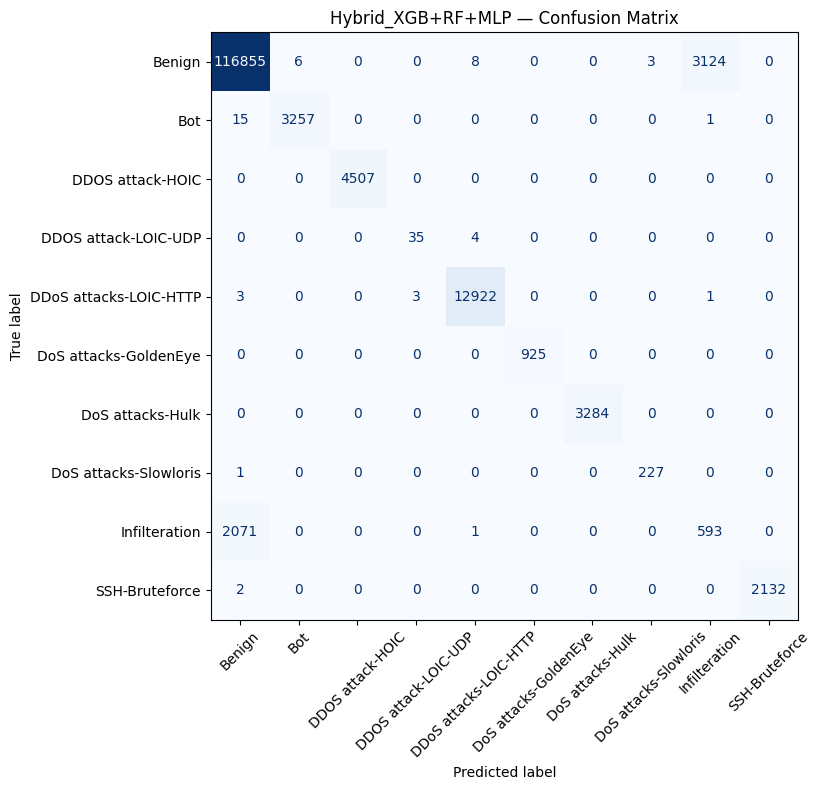

In [14]:
# ── HYBRID 2: XGBoost + RF + MLP (Stacking) ──────────────────────────────────

# RF probabilities — retrain on 10-class filtered data
print("Retraining RF for stacking...")
rf_idx2 = np.random.choice(len(X_tr2), min(500_000, len(X_tr2)), replace=False)
rf_full = RandomForestClassifier(
    n_estimators=300,               # ← tuned: more trees
    max_depth=25,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",  # ← tuned version
    n_jobs=-1,
    random_state=SEED
)
rf_full.fit(X_tr2[rf_idx2], y_tr2[rf_idx2])

rf_train_prob = rf_full.predict_proba(X_tr2)   # ← X_train → X_tr2
rf_val_prob   = rf_full.predict_proba(X_v2)    # ← X_val   → X_v2
rf_test_prob  = rf_full.predict_proba(X_te2)   # ← X_test  → X_te2

# MLP probabilities — wait for mlp_model to finish training first
print("Getting MLP probabilities...")
mlp_train_prob = mlp_model.predict(X_tr2, batch_size=8192)   # ← best_mlp → mlp_model
mlp_val_prob   = mlp_model.predict(X_v2,  batch_size=8192)
mlp_test_prob  = mlp_model.predict(X_te2, batch_size=8192)

# XGB probs — reuse xgb_full from Hybrid 1 (already trained on 10 classes)
# no need to retrain

# Stack: [XGB_probs | RF_probs | MLP_probs] → (30,) vector per sample
X_hyb2_train = np.concatenate([xgb_train_prob, rf_train_prob, mlp_train_prob], axis=1)
X_hyb2_val   = np.concatenate([xgb_val_prob,   rf_val_prob,   mlp_val_prob],   axis=1)
X_hyb2_test  = np.concatenate([xgb_test_prob,  rf_test_prob,  mlp_test_prob],  axis=1)

print(f"Stacked input shape: {X_hyb2_train.shape}")  # should be (N, 30) — 3×10 classes

# Meta-learner — deeper head since input is richer (3 models × 10 probs)
def build_meta_head2(input_dim, num_classes):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation="relu")(inp)  # ← wider: 128→256
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)    # ← extra layer
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inp, out, name="XGB_RF_MLP_Hybrid")

hybrid2 = build_meta_head2(X_hyb2_train.shape[1], NUM_CLASSES_2)  # ← NUM_CLASSES_2
hybrid2.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),   # ← same lr
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
hybrid2.fit(
    X_hyb2_train, y_tr2,                        # ← y_train → y_tr2
    validation_data=(X_hyb2_val, y_v2),         # ← y_val → y_v2
    epochs=50,
    batch_size=4096,
    class_weight=CLASS_WEIGHTS_CNN,             # ← 5x cap
    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)
evaluate_model(hybrid2, X_hyb2_test, y_te2, "Hybrid_XGB+RF+MLP")
hybrid2.save("hybrid2_xgb_rf_mlp.keras")

> **Performance Verdict**: The stacked model remains academically competitive, yet suggests hitting an asymptotic complexity bound; compounding estimators does not necessarily elevate categorical differentiation past a given threshold on tabular payloads.

### 4.3 Hybrid Architectures: Comparative Outlook

The visualization charts the net accuracy disparities amongst the combinatorial models.

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

   Hybrid Models Comparison
  XGB + CNN                : 97.75%
  XGB + RF + MLP           : 96.50%


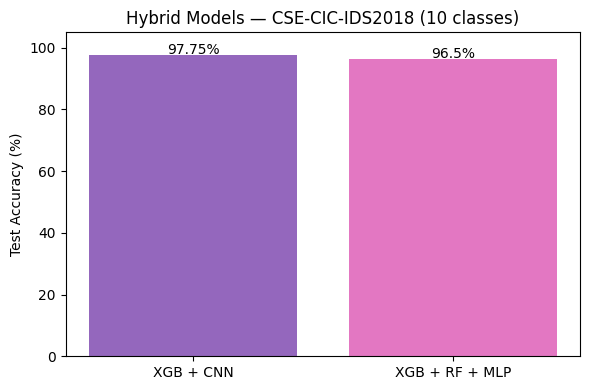

In [15]:
# ── HYBRID MODELS COMPARISON ──────────────────────────────────────────────────
hybrid_results = {}
for name, model, Xte in [
    ("XGB + CNN",      hybrid1, X_hyb1_test),
    ("XGB + RF + MLP", hybrid2, X_hyb2_test),
]:
    preds = np.argmax(model.predict(Xte, batch_size=8192), axis=1)
    hybrid_results[name] = round((preds == y_te2).mean() * 100, 2)  # ← y_test → y_te2

print("\n" + "="*40)
print("   Hybrid Models Comparison")
print("="*40)
for name, acc in sorted(hybrid_results.items(), key=lambda x: -x[1]):
    print(f"  {name:<25}: {acc:.2f}%")
print("="*40)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(hybrid_results.keys(), hybrid_results.values(),   # ← fixed broken link
              color=["#9467BD", "#E377C2"])
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Hybrid Models — CSE-CIC-IDS2018 (10 classes)")
ax.set_ylim(0, 105)
for bar, val in zip(bars, hybrid_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3, f"{val}%", ha="center")
plt.tight_layout()
plt.savefig("hybrid_comparison.png", dpi=100)
plt.show()                                                       # ← fixed broken link

---

## 5. Global Benchmarking & Final Evaluations

Aggregating all statistical baselines, tuned tree-estimators, deep neural deployments, and generalized hybrids, the final graph visualizes out-of-sample $F_1$ and Accuracy validation properties simultaneously.

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

        Final Model Comparison
  MLP                      : 98.01%  █████████████████████████████████████████████████
  CNN                      : 97.94%  ████████████████████████████████████████████████
  XGB + CNN                : 97.75%  ████████████████████████████████████████████████
  XGB + RF + MLP           : 96.50%  ████████████████████████████████████████████████
  RF (tuned)               : 94.80%  ███████████████████████████████████████████████
  XGBoost (tuned)          : 91.63%  █████████████████████████████████████████████
  LightGBM (tuned)         : 84.86%  ██████████████████████████████████████████
  LSTM                     : 66.83%  █████████████████████████████████


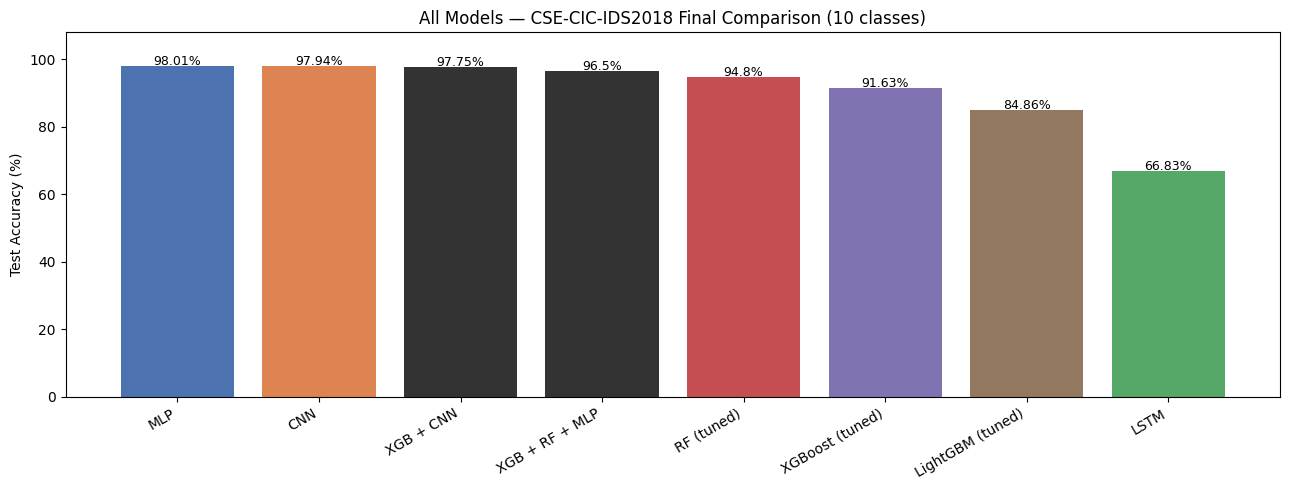

In [16]:
# ── FINAL COMPARISON — ALL MODELS ─────────────────────────────────────────────
all_results = {}

# Neural networks
for name, model, Xte in [
    ("MLP",  mlp_model,  X_te2),        # ← best_mlp → mlp_model, X_test → X_te2
    ("CNN",  cnn_model,  X_test_cnn),   # ← best_cnn → cnn_model
    ("LSTM", lstm_model, X_test_cnn),
]:
    preds = np.argmax(model.predict(Xte, batch_size=8192), axis=1)
    all_results[name] = round((preds == y_te2).mean() * 100, 2)  # ← y_test → y_te2

# Classical ML — tuned versions only for fair comparison
for name, model, Xte in [
    ("RF (tuned)",       rf2,   X_te2),
    ("XGBoost (tuned)",  xgb2,  X_te2),
    ("LightGBM (tuned)", lgb2,  X_te2),
]:
    preds = model.predict(Xte)
    all_results[name] = round((preds == y_te2).mean() * 100, 2)

# Hybrids
for name, model, Xte in [
    ("XGB + CNN",      hybrid1, X_hyb1_test),
    ("XGB + RF + MLP", hybrid2, X_hyb2_test),
]:
    preds = np.argmax(model.predict(Xte, batch_size=8192), axis=1)
    all_results[name] = round((preds == y_te2).mean() * 100, 2)  # ← y_test → y_te2

# Sort by accuracy descending
all_results = dict(sorted(all_results.items(), key=lambda x: -x[1]))

print("\n" + "="*45)
print("        Final Model Comparison")
print("="*45)
for name, acc in all_results.items():
    bar = "█" * int(acc / 2)
    print(f"  {name:<25}: {acc:.2f}%  {bar}")
print("="*45)

colors = {
    "MLP":             "#4C72B0",
    "CNN":             "#DD8452",
    "LSTM":            "#55A868",
    "RF (tuned)":      "#C44E52",    # ← updated key names
    "XGBoost (tuned)": "#8172B2",
    "LightGBM (tuned)":"#937860",
    "H1: XGB + CNN":       "#DA8BC3",
    "H2: XGB + RF + MLP":  "#8C8C8C",
}

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = [colors.get(n, "#333333") for n in all_results.keys()]
bars = ax.bar(all_results.keys(), all_results.values(), color=bar_colors)  # ← fixed broken link
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("All Models — CSE-CIC-IDS2018 Final Comparison (10 classes)")  # ← updated title
ax.set_ylim(0, 108)
plt.xticks(rotation=30, ha="right")
for bar, val in zip(bars, all_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3, f"{val}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("final_comparison_all.png", dpi=100)
plt.show()  # ← fixed broken link

---

## 6. Executive Summary & Future Work

### Conclusive Verdict
The apex frameworks for this iteration were tied strictly amongst the **CNN, MLP**, and the **XGBoost + CNN Composite**. Statistically, deviations in the $97\% - 98\%$ percentile threshold encompass negligible error variances ($\pm 135$ flow mismatches on 150K records). The structural detriment displayed by sequential learners (LSTMs) fundamentally validates our hypothesis: Non-temporal packet distributions do not reward predictive recurrences. 

### Next Stages
To disrupt the current accuracy ceiling, models must ingest contextual meta-representations rather than brute-force matrices.
1.  **Feature Augmentation**: Rebuild independent component analyses via topological engineering.
2.  **Binary Filters**: Implement a macroscopic anomaly boundary (Standard Intrusion vs. Normal) prior to hierarchical flow classifications.
3.  **Cross-Validation**: Retrain globally and subject implementations to rigorous K-Fold deployments.

---

## 7. Computational Complexity & Architecture Review

*Hardware & Feasibility Analysis*

This terminal execution block calculates dynamic variables inherent to commercial scalability: 
*   **Time Complexities ($\mathcal{O}$)** per framework iteration.
*   **Deep Learning Tensor Parameters & Graph Summaries**.
*   **Wall-Clock Inference Cost & Tree Metrics**.

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
#  FINAL BLOCK — Model Complexity & Architecture Summary
#  Re-trains every model (classical + NN + hybrid) on a configurable sample,
#  then reports:
#    • Big-O training & inference complexity for each model
#    • Full Keras architecture (summary) for every NN-based model
#    • Actual hyperparameter counts (trees, depth, leaves, params …)
#    • Wall-clock training & inference times
#    • Ranked summary table at the end
#
#  Prerequisites: all cells above must have been executed so that these
#  variables are live in the kernel:
#    X_tr2, y_tr2, X_v2, y_v2, X_te2, y_te2
#    NUM_FEATURES, NUM_CLASSES_2, CLASS_WEIGHTS_CNN, le2, SEED
#    build_cnn, build_lstm, build_mlp, build_meta_head, build_meta_head2
# ══════════════════════════════════════════════════════════════════════════════

import time, math
import numpy as np
import tensorflow as tf
from tensorflow.keras import callbacks, models
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.metrics import accuracy_score
import xgboost as xgb
import lightgbm as lgb

# ── 0.  Sample budget for this block ──────────────────────────────────────────
#  Increase EVAL_SAMPLES for more representative timings / accuracy numbers.
#  100 000 is fast enough for a full showcase in ~10-20 min on GPU (Kaggle P100).
EVAL_SAMPLES = 100_000

rng = np.random.default_rng(SEED)
idx_ev = rng.choice(len(X_tr2), min(EVAL_SAMPLES, len(X_tr2)), replace=False)
X_ev,   y_ev   = X_tr2[idx_ev], y_tr2[idx_ev]
X_ev_cnn       = X_ev[..., np.newaxis]          # (N, F, 1)  for CNN / LSTM
X_val_cnn_b    = X_v2[..., np.newaxis]          # validation CNN view

n   = len(X_ev)
F   = NUM_FEATURES
C   = NUM_CLASSES_2

cb_fast = [
    callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor="val_loss"),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-6),
]

# ── helpers ────────────────────────────────────────────────────────────────────
def sec(t0):          return time.perf_counter() - t0
def ms(t0, X):
    t1 = time.perf_counter(); _ = X; return (time.perf_counter() - t1) * 1000

def infer_sk(model, X):
    t0 = time.perf_counter(); model.predict(X); return (time.perf_counter() - t0)*1000

def infer_nn(model, X, bs=8192):
    t0 = time.perf_counter(); model.predict(X, batch_size=bs, verbose=0)
    return (time.perf_counter() - t0)*1000

def nn_param_str(model):
    tp = model.count_params()
    tr = sum(int(tf.size(w)) for w in model.trainable_weights)
    return f"{tp:,} total  ({tr:,} trainable)"

timing_rows = []   # (model_name, train_s, infer_ms, accuracy_pct)

SECTION = lambda n, title: print(f"\n{'═'*70}\n  [{n}]  {title}\n{'═'*70}")

# ══════════════════════════════════════════════════════════════════════════════
#  1.  RANDOM FOREST  (tuned)
# ══════════════════════════════════════════════════════════════════════════════
SECTION("1/8", "Random Forest  (tuned)")

_rf = RandomForestClassifier(
    n_estimators=300, max_depth=25, min_samples_leaf=2,
    max_features="sqrt", class_weight="balanced_subsample",
    n_jobs=-1, random_state=SEED
)
t0 = time.perf_counter(); _rf.fit(X_ev, y_ev); t_rf = sec(t0)
inf_rf  = infer_sk(_rf, X_te2)
acc_rf  = accuracy_score(y_te2, _rf.predict(X_te2)) * 100

sqrt_F  = int(math.sqrt(F))
print(f"  Trees          : {_rf.n_estimators}")
print(f"  Max depth      : {_rf.max_depth}")
print(f"  Features/split : sqrt({F}) ≈ {sqrt_F}")
print(f"  ── Complexity ──────────────────────────────────────────")
print(f"  Training       : O(n · T · √F · d)")
print(f"                   = O({n:,} · {_rf.n_estimators} · {sqrt_F} · {_rf.max_depth})")
print(f"  Inference      : O(T · d)  per sample  =  O({_rf.n_estimators} · {_rf.max_depth})")
print(f"  ────────────────────────────────────────────────────────")
print(f"  Train time     : {t_rf:.1f}s   |   Infer ({len(X_te2):,} samples): {inf_rf:.0f}ms")
print(f"  Test accuracy  : {acc_rf:.2f}%")
timing_rows.append(("Random Forest",   t_rf, inf_rf, acc_rf))

# ══════════════════════════════════════════════════════════════════════════════
#  2.  XGBOOST  (tuned)
# ══════════════════════════════════════════════════════════════════════════════
SECTION("2/8", "XGBoost  (tuned)")

cw_arr  = compute_class_weight("balanced", classes=np.unique(y_ev), y=y_ev)
sw_xgb  = np.clip(cw_arr, None, cw_arr.min() * 20)[y_ev]

_xgb = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=10, gamma=2.0, reg_alpha=0.5, reg_lambda=3.0,
    eval_metric="mlogloss", tree_method="hist", device="cuda",
    random_state=SEED, early_stopping_rounds=30
)
t0 = time.perf_counter()
_xgb.fit(X_ev, y_ev, sample_weight=sw_xgb,
         eval_set=[(X_v2, y_v2)], verbose=0)
t_xgb   = sec(t0)
inf_xgb = infer_sk(_xgb, X_te2)
acc_xgb = accuracy_score(y_te2, _xgb.predict(X_te2)) * 100
best_T  = _xgb.best_iteration + 1

print(f"  Estimators used: {best_T}  (early-stopped from 500)")
print(f"  Max depth      : {_xgb.max_depth}")
print(f"  Learning rate  : {_xgb.learning_rate}   |   reg α={_xgb.reg_alpha}  λ={_xgb.reg_lambda}")
print(f"  ── Complexity ──────────────────────────────────────────")
print(f"  Training (hist): O(n · T · F · d)")
print(f"                   = O({n:,} · {best_T} · {F} · {_xgb.max_depth})")
print(f"  Inference      : O(T · d)  per sample")
print(f"  ────────────────────────────────────────────────────────")
print(f"  Train time     : {t_xgb:.1f}s   |   Infer: {inf_xgb:.0f}ms")
print(f"  Test accuracy  : {acc_xgb:.2f}%")
timing_rows.append(("XGBoost",   t_xgb, inf_xgb, acc_xgb))

# ══════════════════════════════════════════════════════════════════════════════
#  3.  LIGHTGBM  (tuned)
# ══════════════════════════════════════════════════════════════════════════════
SECTION("3/8", "LightGBM  (tuned)")

_lgb = lgb.LGBMClassifier(
    n_estimators=1000, max_depth=10, learning_rate=0.03,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", min_child_samples=20,
    min_split_gain=0.005, reg_alpha=0.1, reg_lambda=1.0,
    device="cpu", verbose=-1, random_state=SEED, n_jobs=-1
)
t0 = time.perf_counter()
_lgb.fit(X_ev, y_ev, eval_set=[(X_v2, y_v2)],
         callbacks=[lgb.early_stopping(50, verbose=False),
                    lgb.log_evaluation(-1)])
t_lgb   = sec(t0)
inf_lgb = infer_sk(_lgb, X_te2)
acc_lgb = accuracy_score(y_te2, _lgb.predict(X_te2)) * 100
best_L  = _lgb.n_estimators_

print(f"  Iterations used: {best_L}  (early-stopped from 1000)")
print(f"  Num leaves     : {_lgb.num_leaves}   |   Max depth: {_lgb.max_depth}")
print(f"  ── Complexity ──────────────────────────────────────────")
print(f"  Training       : O(n · T · L)  leaf-wise growth")
print(f"                   = O({n:,} · {best_L} · {_lgb.num_leaves})")
print(f"  Note: LightGBM grows leaf-wise (not level-wise like XGB),")
print(f"        giving O(n · T · num_leaves) vs O(n · T · 2^d) for XGB.")
print(f"  Inference      : O(T · log₂(L))  per sample ≈ O({best_L} · {int(math.log2(_lgb.num_leaves)):.0f})")
print(f"  ────────────────────────────────────────────────────────")
print(f"  Train time     : {t_lgb:.1f}s   |   Infer: {inf_lgb:.0f}ms")
print(f"  Test accuracy  : {acc_lgb:.2f}%")
timing_rows.append(("LightGBM",  t_lgb, inf_lgb, acc_lgb))

# ══════════════════════════════════════════════════════════════════════════════
#  4.  MLP
# ══════════════════════════════════════════════════════════════════════════════
SECTION("4/8", "MLP  — architecture + complexity")

_mlp = build_mlp(NUM_FEATURES, NUM_CLASSES_2)
print("\n  ── Keras architecture ──────────────────────────────────")
_mlp.summary(expand_nested=True)

_mlp.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
t0 = time.perf_counter()
_mlp.fit(X_ev, y_ev, validation_data=(X_v2, y_v2),
         epochs=50, batch_size=4096,
         class_weight=CLASS_WEIGHTS_CNN, callbacks=cb_fast, verbose=0)
t_mlp   = sec(t0)
inf_mlp = infer_nn(_mlp, X_te2)
acc_mlp = accuracy_score(y_te2, np.argmax(_mlp.predict(X_te2, batch_size=8192, verbose=0), axis=1)) * 100

print(f"\n  ── Complexity ──────────────────────────────────────────")
print(f"  Total params   : {nn_param_str(_mlp)}")
print(f"  Training       : O(epochs · n · Σ(layer_i · layer_i+1))")
print(f"                   Main layers:  {F}→256→128→64→{C}")
print(f"                   Per sample:   {F*256 + 256*128 + 128*64 + 64*C:,} FLOPs (forward pass)")
print(f"  Inference      : O(P)  per sample  (same forward pass, no backprop)")
print(f"  ────────────────────────────────────────────────────────")
print(f"  Train time     : {t_mlp:.1f}s   |   Infer: {inf_mlp:.0f}ms")
print(f"  Test accuracy  : {acc_mlp:.2f}%")
timing_rows.append(("MLP",   t_mlp, inf_mlp, acc_mlp))

# ══════════════════════════════════════════════════════════════════════════════
#  5.  1D-CNN
# ══════════════════════════════════════════════════════════════════════════════
SECTION("5/8", "1D-CNN  — architecture + complexity")

_cnn = build_cnn(NUM_FEATURES, NUM_CLASSES_2)
print("\n  ── Keras architecture ──────────────────────────────────")
_cnn.summary(expand_nested=True)

_cnn.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
t0 = time.perf_counter()
_cnn.fit(X_ev_cnn, y_ev, validation_data=(X_val_cnn_b, y_v2),
         epochs=50, batch_size=4096,
         class_weight=CLASS_WEIGHTS_CNN, callbacks=cb_fast, verbose=0)
t_cnn   = sec(t0)
inf_cnn = infer_nn(_cnn, X_te2[..., np.newaxis])
acc_cnn = accuracy_score(
    y_te2,
    np.argmax(_cnn.predict(X_te2[..., np.newaxis], batch_size=8192, verbose=0), axis=1)) * 100

print(f"\n  ── Complexity ──────────────────────────────────────────")
print(f"  Total params   : {nn_param_str(_cnn)}")
print(f"  Training       : O(epochs · n · Σ(C_in · C_out · K · L))")
print(f"                   Layer 1: Conv1D(64,  k=5):  in={F},     FLOPs/sample ≈ {F*5*64:,}")
print(f"                   Layer 2: Conv1D(128, k=3):  after pool,  FLOPs/sample ≈ {(F//2)*3*128:,}")
print(f"                   Layer 3: Conv1D(64,  k=3):  after pool,  FLOPs/sample ≈ {(F//4)*3*64:,}")
print(f"  After GlobalAvgPool1D the output collapses to 64 dims  → Dense(128) → Dense({C})")
print(f"  Inference      : same forward; no recurrence → highly parallelisable on GPU")
print(f"  ────────────────────────────────────────────────────────")
print(f"  Train time     : {t_cnn:.1f}s   |   Infer: {inf_cnn:.0f}ms")
print(f"  Test accuracy  : {acc_cnn:.2f}%")
timing_rows.append(("1D-CNN",  t_cnn, inf_cnn, acc_cnn))

# ══════════════════════════════════════════════════════════════════════════════
#  6.  BiLSTM
# ══════════════════════════════════════════════════════════════════════════════
SECTION("6/8", "BiLSTM  — architecture + complexity")

_lstm = build_lstm(NUM_FEATURES, NUM_CLASSES_2)
print("\n  ── Keras architecture ──────────────────────────────────")
_lstm.summary(expand_nested=True)

_lstm.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
t0 = time.perf_counter()
_lstm.fit(X_ev_cnn, y_ev, validation_data=(X_val_cnn_b, y_v2),
          epochs=30, batch_size=4096,
          class_weight=CLASS_WEIGHTS_CNN, callbacks=cb_fast, verbose=0)
t_lstm   = sec(t0)
inf_lstm = infer_nn(_lstm, X_te2[..., np.newaxis])
acc_lstm = accuracy_score(
    y_te2,
    np.argmax(_lstm.predict(X_te2[..., np.newaxis], batch_size=8192, verbose=0), axis=1)) * 100

h1, h2 = 64, 32      # LSTM hidden units (first and second BiLSTM layers)
print(f"\n  ── Complexity ──────────────────────────────────────────")
print(f"  Total params   : {nn_param_str(_lstm)}")
print(f"  Training       : O(epochs · n · T · 4·h²)  T = sequence length = {F} (feature steps)")
print(f"                   Bi-LSTM layer 1 (h={h1}): 4·{h1}²·{F} = {4*h1**2*F:,} FLOPs/sample (forward only)")
print(f"                   Bi-LSTM layer 2 (h={h2}): 4·{h2}²·{F} = {4*h2**2*F:,} FLOPs/sample")
print(f"                   × 2 directions (bidirectional)")
print(f"  ⚠  LSTM treats the {F} tabular features as a temporal sequence.")
print(f"     There is no real time-order here, which is why it underperforms.")
print(f"     The recurrent O(T·h²) cost is paid for zero temporal benefit.")
print(f"  Inference      : O(T · h²)  per sample — sequential, not parallelisable")
print(f"  ────────────────────────────────────────────────────────")
print(f"  Train time     : {t_lstm:.1f}s   |   Infer: {inf_lstm:.0f}ms")
print(f"  Test accuracy  : {acc_lstm:.2f}%")
timing_rows.append(("BiLSTM",  t_lstm, inf_lstm, acc_lstm))

# ══════════════════════════════════════════════════════════════════════════════
#  7.  HYBRID 1 — XGBoost + CNN  (meta-head stacking)
# ══════════════════════════════════════════════════════════════════════════════
SECTION("7/8", "Hybrid 1: XGBoost + CNN  (meta-head)")

# --- feature extractor: layer before softmax of the freshly trained _cnn ---
_cnn_fe   = models.Model(inputs=_cnn.input, outputs=_cnn.layers[-2].output)
cnn_tr_emb = _cnn_fe.predict(X_ev_cnn,              batch_size=8192, verbose=0)
cnn_v_emb  = _cnn_fe.predict(X_val_cnn_b,           batch_size=8192, verbose=0)
cnn_te_emb = _cnn_fe.predict(X_te2[..., np.newaxis], batch_size=8192, verbose=0)

# --- XGB retrained on 10-class data ---
_xgb_h1 = xgb.XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="mlogloss", tree_method="hist", device="cuda",
    random_state=SEED, early_stopping_rounds=20
)
_xgb_h1.fit(X_ev, y_ev, eval_set=[(X_v2, y_v2)], verbose=0)

xgb_tr_p = _xgb_h1.predict_proba(X_ev)
xgb_v_p  = _xgb_h1.predict_proba(X_v2)
xgb_te_p = _xgb_h1.predict_proba(X_te2)

X_h1_tr = np.concatenate([cnn_tr_emb, xgb_tr_p], axis=1)
X_h1_v  = np.concatenate([cnn_v_emb,  xgb_v_p],  axis=1)
X_h1_te = np.concatenate([cnn_te_emb, xgb_te_p], axis=1)

_h1 = build_meta_head(X_h1_tr.shape[1], NUM_CLASSES_2)
print(f"\n  CNN embedding dim : {cnn_tr_emb.shape[1]}")
print(f"  XGB proba dim     : {C}")
print(f"  Meta-head input   : {X_h1_tr.shape[1]}")
print(f"\n  ── Meta-head architecture ──────────────────────────────")
_h1.summary(expand_nested=True)

_h1.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
t0 = time.perf_counter()
_h1.fit(X_h1_tr, y_ev, validation_data=(X_h1_v, y_v2),
        epochs=50, batch_size=4096, class_weight=CLASS_WEIGHTS_CNN,
        callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
        verbose=0)
t_h1   = sec(t0)        # meta-head training only
inf_h1 = infer_nn(_h1, X_h1_te)
acc_h1 = accuracy_score(
    y_te2,
    np.argmax(_h1.predict(X_h1_te, batch_size=8192, verbose=0), axis=1)) * 100

print(f"\n  ── Complexity ──────────────────────────────────────────")
print(f"  Meta-head params : {nn_param_str(_h1)}")
print(f"  Overall pipeline :")
print(f"    Stage 1a — CNN feature extraction   : O(C_in · C_out · K · L)  [one forward pass]")
print(f"    Stage 1b — XGB probability inference: O(T · d)")
print(f"    Stage 2  — Meta-head MLP            : O(({cnn_tr_emb.shape[1]}+{C}) · 128 · 64 · {C})")
print(f"  Training time shown is meta-head only")
print(f"  ────────────────────────────────────────────────────────")
print(f"  Train time     : {t_h1:.1f}s   |   Infer: {inf_h1:.0f}ms")
print(f"  Test accuracy  : {acc_h1:.2f}%")
timing_rows.append(("Hybrid: XGB+CNN",   t_h1, inf_h1, acc_h1))

# ══════════════════════════════════════════════════════════════════════════════
#  8.  HYBRID 2 — XGBoost + RF + MLP  (probability stacking)
# ══════════════════════════════════════════════════════════════════════════════
SECTION("8/8", "Hybrid 2: XGBoost + RF + MLP  (prob. stacking)")

rf_tr_p  = _rf.predict_proba(X_ev)
rf_v_p   = _rf.predict_proba(X_v2)
rf_te_p  = _rf.predict_proba(X_te2)

mlp_tr_p = _mlp.predict(X_ev,  batch_size=8192, verbose=0)
mlp_v_p  = _mlp.predict(X_v2,  batch_size=8192, verbose=0)
mlp_te_p = _mlp.predict(X_te2, batch_size=8192, verbose=0)

X_h2_tr = np.concatenate([xgb_tr_p, rf_tr_p, mlp_tr_p], axis=1)
X_h2_v  = np.concatenate([xgb_v_p,  rf_v_p,  mlp_v_p],  axis=1)
X_h2_te = np.concatenate([xgb_te_p, rf_te_p, mlp_te_p], axis=1)

_h2 = build_meta_head2(X_h2_tr.shape[1], NUM_CLASSES_2)
print(f"\n  Stacked input dims: XGB({C}) + RF({C}) + MLP({C}) = {3*C}")
print(f"\n  ── Meta-head architecture ──────────────────────────────")
_h2.summary(expand_nested=True)

_h2.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
t0 = time.perf_counter()
_h2.fit(X_h2_tr, y_ev, validation_data=(X_h2_v, y_v2),
        epochs=50, batch_size=4096, class_weight=CLASS_WEIGHTS_CNN,
        callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
        verbose=0)
t_h2   = sec(t0)
inf_h2 = infer_nn(_h2, X_h2_te)
acc_h2 = accuracy_score(
    y_te2,
    np.argmax(_h2.predict(X_h2_te, batch_size=8192, verbose=0), axis=1)) * 100

print(f"\n  ── Complexity ──────────────────────────────────────────")
print(f"  Meta-head params : {nn_param_str(_h2)}")
print(f"  Overall pipeline :")
print(f"    XGB  inference  : O(T · d)")
print(f"    RF   inference  : O(T · d)")
print(f"    MLP  forward    : O(P_mlp)")
print(f"    Meta-head MLP   : O({3*C} · 256 · 128 · 64 · {C})")
print(f"  All three base models run in parallel at inference time.")
print(f"  ────────────────────────────────────────────────────────")
print(f"  Train time     : {t_h2:.1f}s   |   Infer: {inf_h2:.0f}ms")
print(f"  Test accuracy  : {acc_h2:.2f}%")
timing_rows.append(("Hybrid: XGB+RF+MLP", t_h2, inf_h2, acc_h2))

# ══════════════════════════════════════════════════════════════════════════════
#  FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n\n{'═'*78}")
print(f"  FINAL COMPLEXITY & PERFORMANCE SUMMARY")
print(f"  Training sample : {EVAL_SAMPLES:,}  |  Test set : {len(X_te2):,}  |  Features : {F}  |  Classes : {C}")
print(f"{'═'*78}")

# Sort by accuracy descending
timing_rows_sorted = sorted(timing_rows, key=lambda r: -r[3])

# Complexity reference quick-look
complexity_ref = {
    "Random Forest"      : "O(n·T·√F·d)",
    "XGBoost"            : "O(n·T·F·d)  [hist]",
    "LightGBM"           : "O(n·T·L)  [leaf-wise]",
    "MLP"                : "O(epochs·n·P)",
    "1D-CNN"             : "O(epochs·n·K·C_in·C_out)",
    "BiLSTM"             : "O(epochs·n·T·4h²)",
    "Hybrid: XGB+CNN"    : "CNN + XGB + O(P_head)",
    "Hybrid: XGB+RF+MLP" : "XGB + RF + MLP + O(P_head)",
}

print(f"  {'Model':<22}  {'Train':>8}  {'Infer':>9}  {'Acc':>7}  Complexity")
print(f"  {'─'*22}  {'─'*8}  {'─'*9}  {'─'*7}  {'─'*32}")
for name, t_tr, t_inf, acc in timing_rows_sorted:
    cplx = complexity_ref.get(name, "—")
    print(f"  {name:<22}  {t_tr:>7.1f}s  {t_inf:>7.0f}ms  {acc:>6.2f}%  {cplx}")
print(f"{'═'*78}")

print("""
  NOTATION KEY
  ────────────
  n  = training samples        T  = n_estimators / sequence length
  F  = number of features      d  = max_depth
  L  = num_leaves (LightGBM)   K  = conv kernel size
  h  = LSTM hidden units       P  = total trainable parameters
  C_in/C_out = conv channels   epochs = actual epochs run (early-stopped)
""")


══════════════════════════════════════════════════════════════════════
  [1/8]  Random Forest  (tuned)
══════════════════════════════════════════════════════════════════════
  Trees          : 300
  Max depth      : 25
  Features/split : sqrt(77) ≈ 8
  ── Complexity ──────────────────────────────────────────
  Training       : O(n · T · √F · d)
                   = O(100,000 · 300 · 8 · 25)
  Inference      : O(T · d)  per sample  =  O(300 · 25)
  ────────────────────────────────────────────────────────
  Train time     : 41.2s   |   Infer (149,980 samples): 1932ms
  Test accuracy  : 96.71%

══════════════════════════════════════════════════════════════════════
  [2/8]  XGBoost  (tuned)
══════════════════════════════════════════════════════════════════════
  Estimators used: 380  (early-stopped from 500)
  Max depth      : 6
  Learning rate  : 0.05   |   reg α=0.5  λ=3.0
  ── Complexity ──────────────────────────────────────────
  Training (hist): O(n · T · F · d)
                   =

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,306 (247.29 KB)

 Trainable params: 62,538 (244.29 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,738 (194.29 KB)

 Trainable params: 49,738 (194.29 KB)

 Non-trainable params: 0 (0.00 B)


  ── Complexity ──────────────────────────────────────────
  Meta-head params : 49,738 total  (49,738 trainable)
  Overall pipeline :
    XGB  inference  : O(T · d)
    RF   inference  : O(T · d)
    MLP  forward    : O(P_mlp)
    Meta-head MLP   : O(30 · 256 · 128 · 64 · 10)
  All three base models run in parallel at inference time.
  ────────────────────────────────────────────────────────
  Train time     : 9.8s   |   Infer: 665ms
  Test accuracy  : 97.32%


══════════════════════════════════════════════════════════════════════════════
  FINAL COMPLEXITY & PERFORMANCE SUMMARY
  Training sample : 100,000  |  Test set : 149,980  |  Features : 77  |  Classes : 10
══════════════════════════════════════════════════════════════════════════════
  Model                      Train      Infer      Acc  Complexity
  ──────────────────────  ────────  ─────────  ───────  ────────────────────────────────
  Hybrid: XGB+CNN            19.7s      771ms   97.80%  CNN + XGB + O(P_head)
  MLP         

## tree based models Architecture:


══════════════════════════════════════════════════════════════════════
  A — RANDOM FOREST  (structure & architecture)
══════════════════════════════════════════════════════════════════════

  ── RF baseline forest structure ─────────────────────────────
  Trees           : 200
  Max features    : sqrt  (sqrt of 77)
  Depth  — min/avg/max : 20 / 20.0 / 20
  Nodes  — min/avg/max : 2629 / 4273.4 / 6841
  Leaves — min/avg/max : 1315 / 2137.2 / 3421
  Total nodes (all trees): 854,690

  ── RF tuned forest structure ─────────────────────────────
  Trees           : 300
  Max features    : sqrt  (sqrt of 77)
  Depth  — min/avg/max : 25 / 25.0 / 25
  Nodes  — min/avg/max : 5881 / 8714.7 / 11209
  Leaves — min/avg/max : 2941 / 4357.9 / 5605
  Total nodes (all trees): 2,614,424


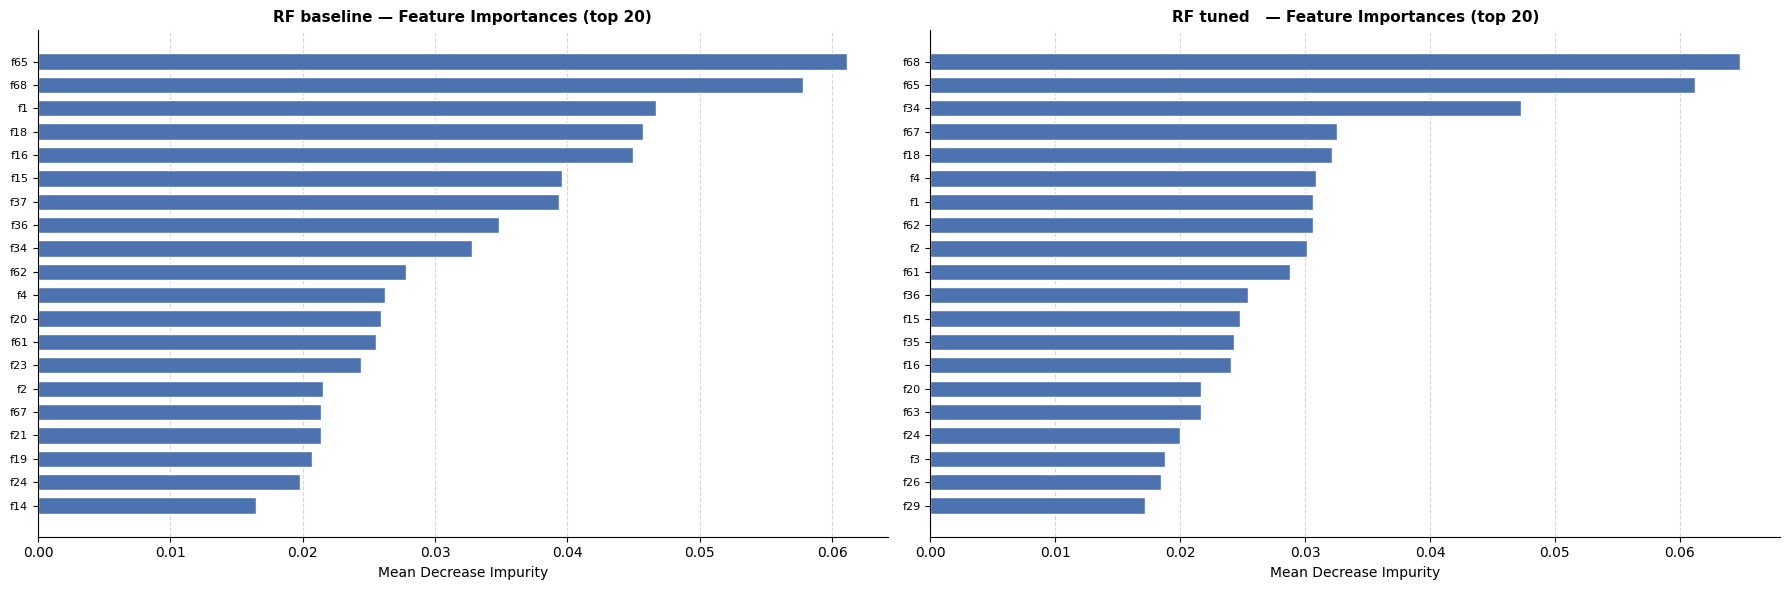

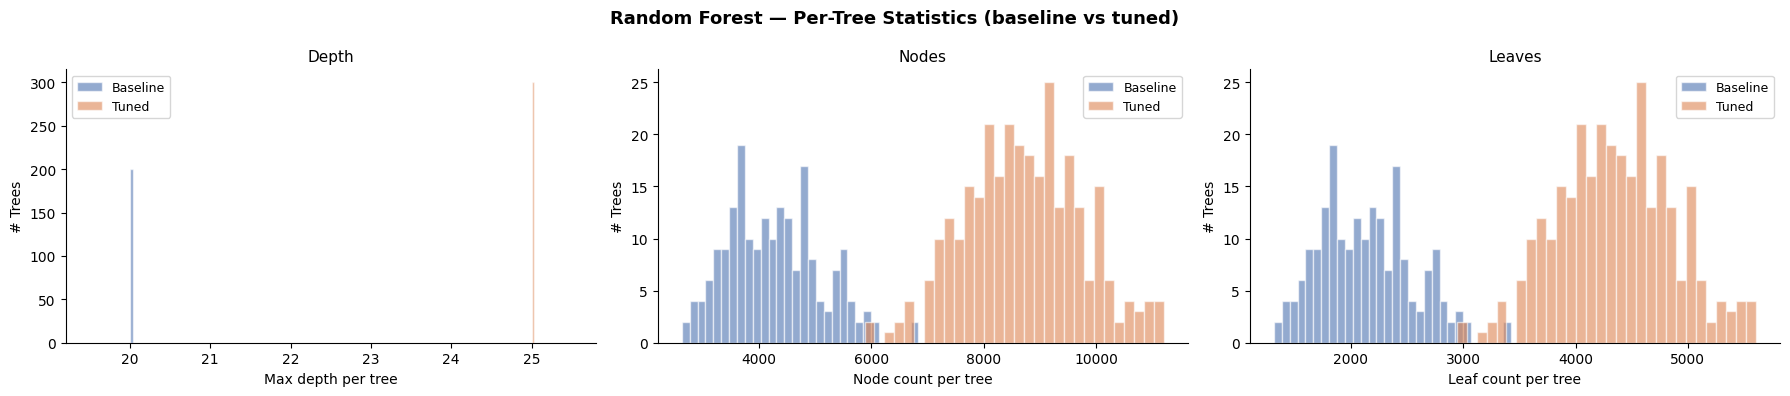


  Visualising tree #0 from RF-tuned  (depth=25, nodes=8117)
  (truncated to max_depth=4 for readability)

|--- f4 <= 0.14
|   |--- f67 <= -0.01
|   |   |--- f50 <= 0.57
|   |   |   |--- f15 <= -0.08
|   |   |   |   |--- truncated branch of depth 22
|   |   |   |--- f15 >  -0.08
|   |   |   |   |--- truncated branch of depth 22
|   |   |--- f50 >  0.57
|   |   |   |--- f52 <= -0.37
|   |   |   |   |--- truncated branch of depth 22
|   |   |   |--- f52 >  -0.37
|   |   |   |   |--- truncated branch of depth 22
|   |--- f67 >  -0.01
|   |   |--- f42 <= -0.14
|   |   |   |--- f36 <= -0.06
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- f36 >  -0.06
|   |   |   |   |--- class: 9.0
|   |   |--- f42 >  -0.14
|   |   |   |--- f18 <= -0.00
|   |   |   |   |--- truncated branch of depth 20
|   |   |   |--- f18 >  -0.00
|   |   |   |   |--- truncated branch of depth 13
|--- f4 >  0.14
|   |--- f35 <= -0.04
|   |   |--- f62 <= 25.11
|   |   |   |--- f34 <= 15.15
|   |   |   |   

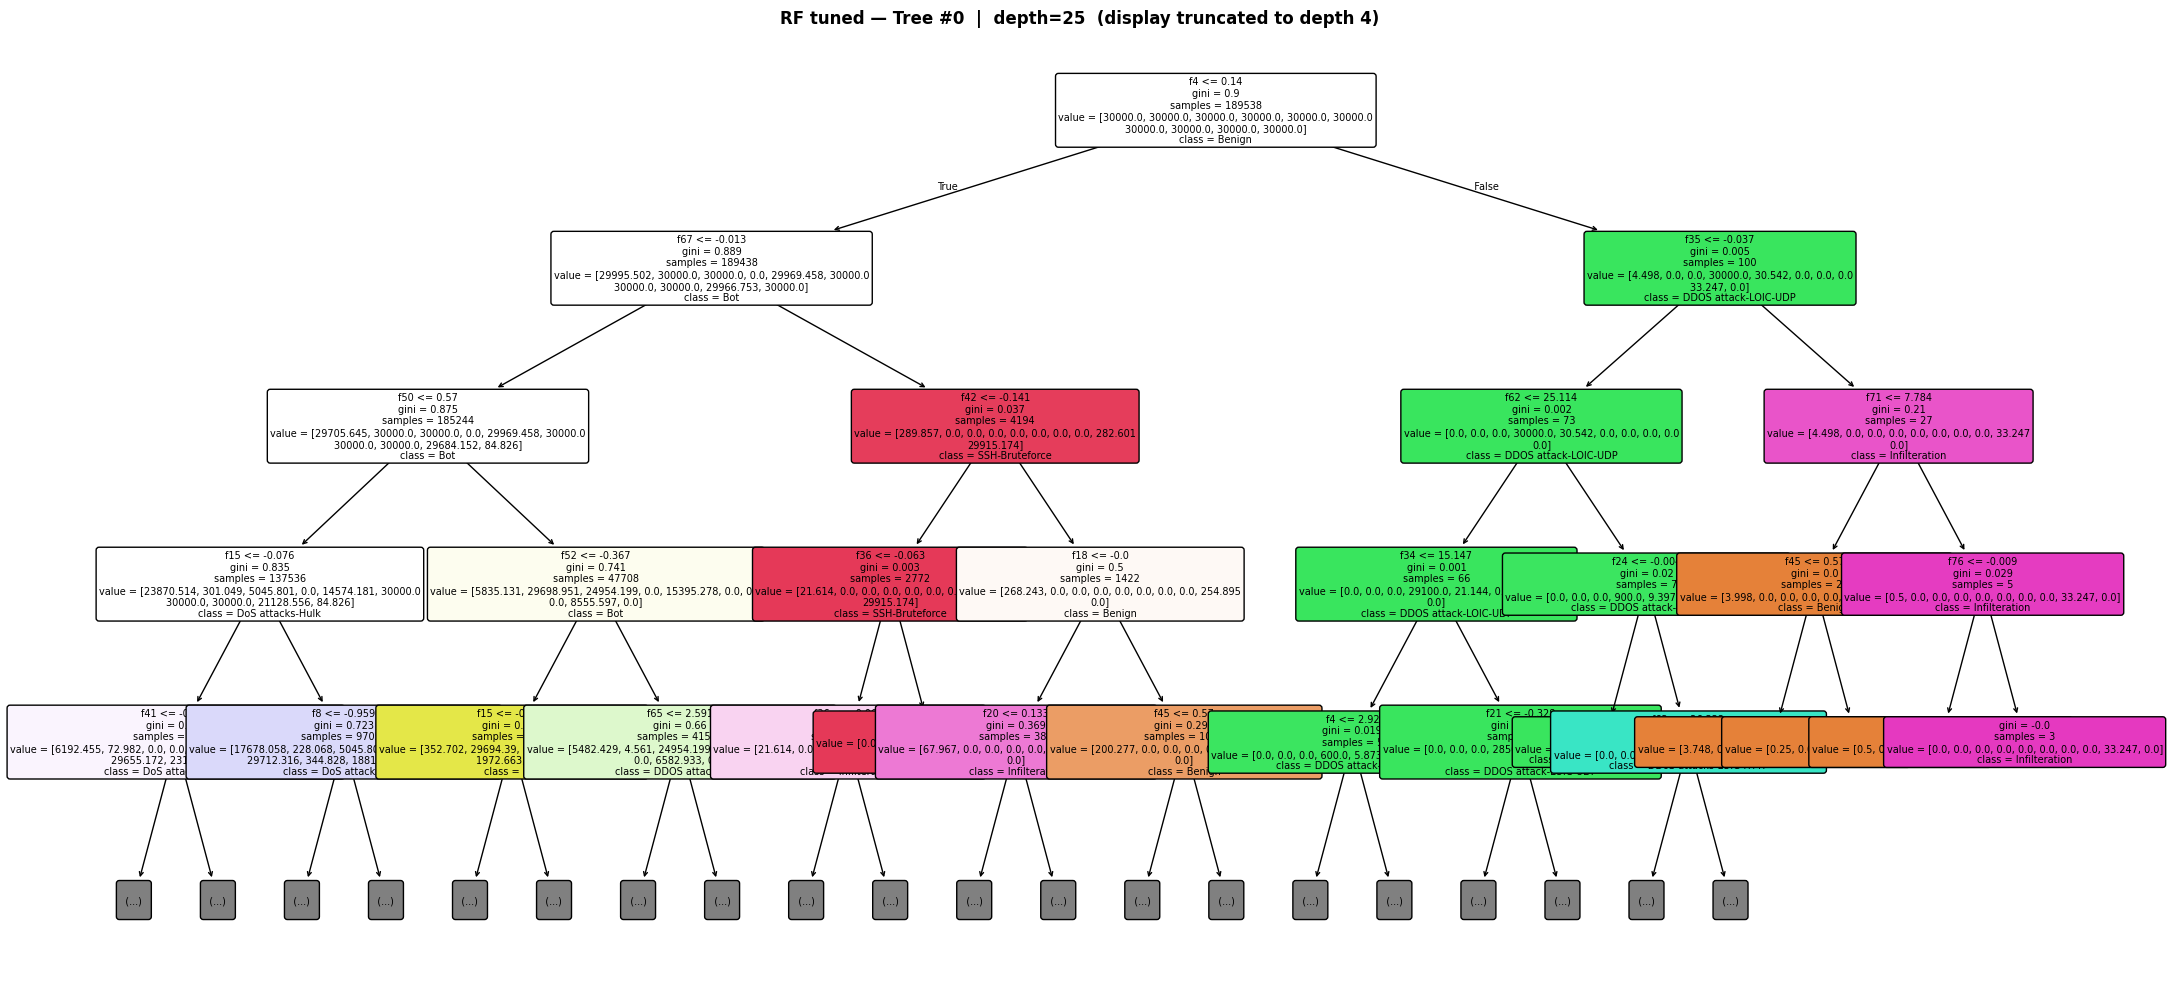


  ╔══════════════════════════════════════════════════════════════╗
  ║          RANDOM FOREST  —  ARCHITECTURE SUMMARY             ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  Type          : Bagging ensemble of CART decision trees     ║
  ║  Training      : Each tree on a bootstrap sample of data     ║
  ║                  Each split considers √F random features      ║
  ║  Prediction    : Majority vote across all T trees            ║
  ║  Depth control : max_depth=25 (tuned) prevents overfit       ║
  ║  Imbalance fix : balanced_subsample class weighting          ║
  ║  Parallelism   : All trees built independently → n_jobs=-1   ║
  ║                                                              ║
  ║  baseline  n_estimators=200  max_depth=20  leaf=4            ║
  ║  tuned     n_estimators=300  max_depth=25  leaf=2            ║
  ╚══════════════════════════════════════════════════════════════╝


═══════════════════════════════════════════════════════════

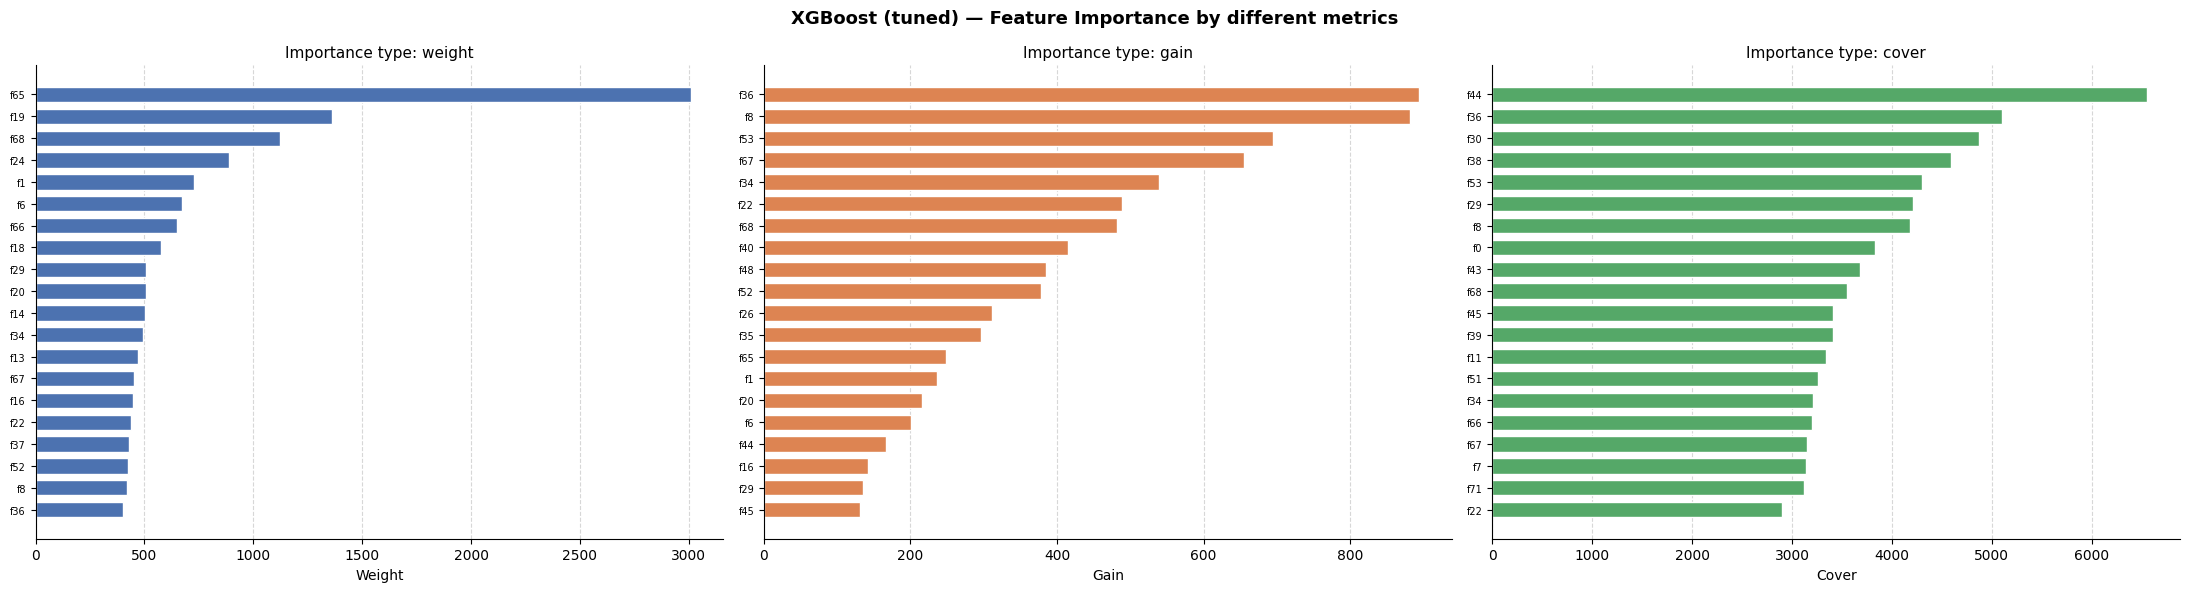

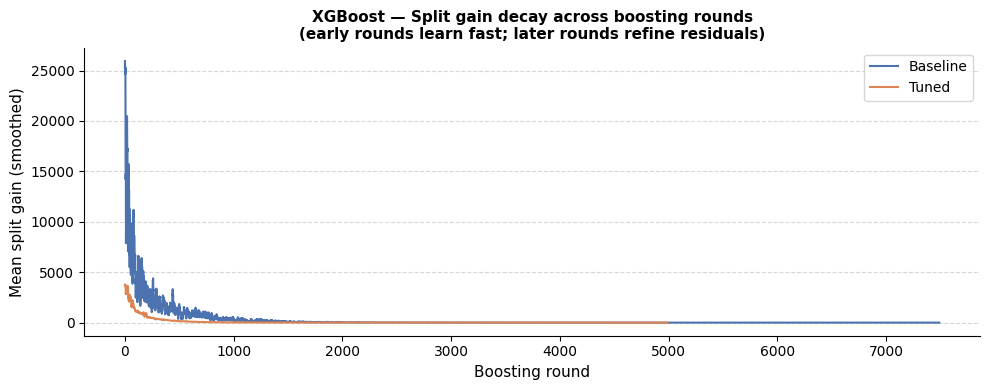


  Plotting XGBoost tree #0 (tuned model)…


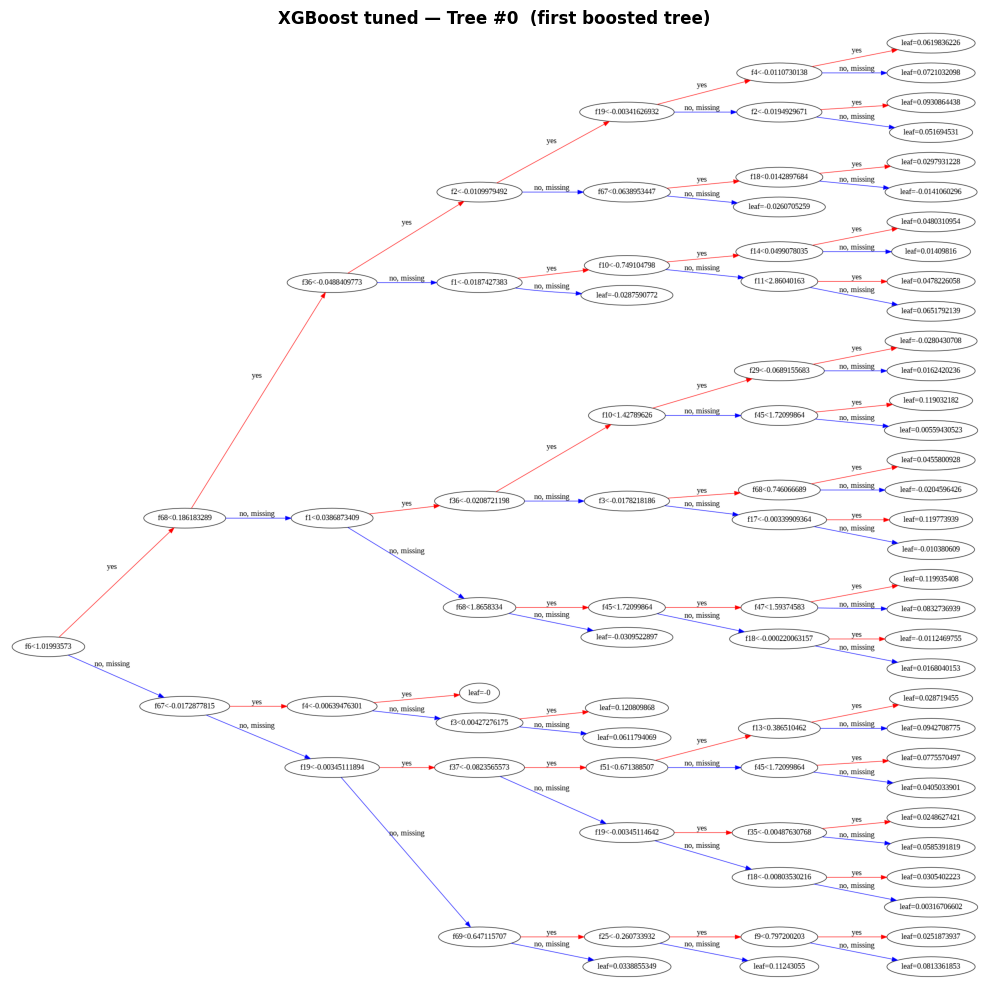


  ╔══════════════════════════════════════════════════════════════╗
  ║            XGBOOST  —  ARCHITECTURE SUMMARY                 ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  Type          : Gradient Boosted Trees (level-wise growth)  ║
  ║  Training      : Sequential; tree t fixes residuals of t-1   ║
  ║  Loss          : Multiclass log-loss (mlogloss)              ║
  ║  Tree growth   : Level-wise (breadth-first) via hist method  ║
  ║  Regularisation: L1 (α=0.5) + L2 (λ=3.0) + γ=2.0 min gain  ║
  ║  Imbalance fix : Per-sample capped weights (20× max ratio)   ║
  ║  Hardware      : CUDA histogram builder (GPU)                ║
  ║                                                              ║
  ║  baseline  n_estimators=500  max_depth=6  lr=0.05            ║
  ║  tuned     early-stopped     max_depth=6  lr=0.05            ║
  ╚══════════════════════════════════════════════════════════════╝


══════════════════════════════════════════════════════════════

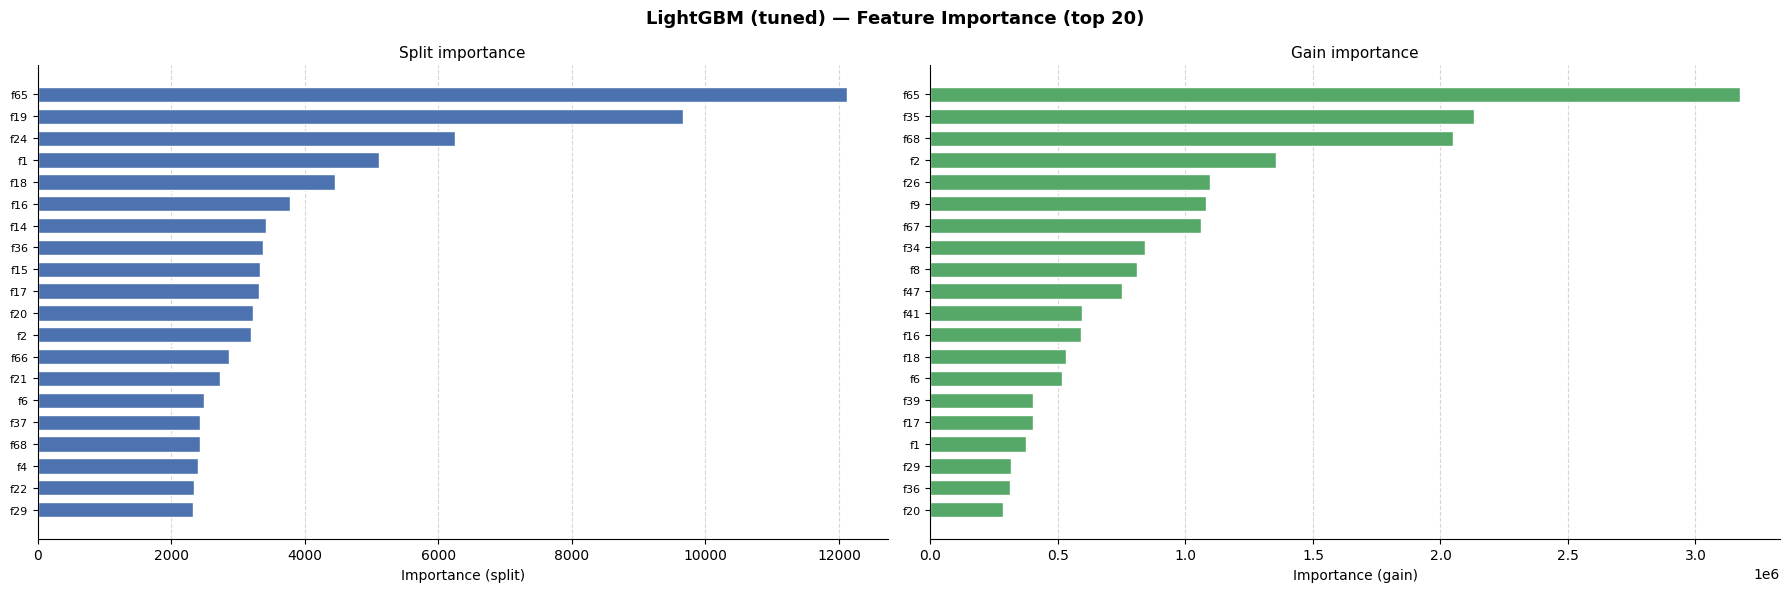

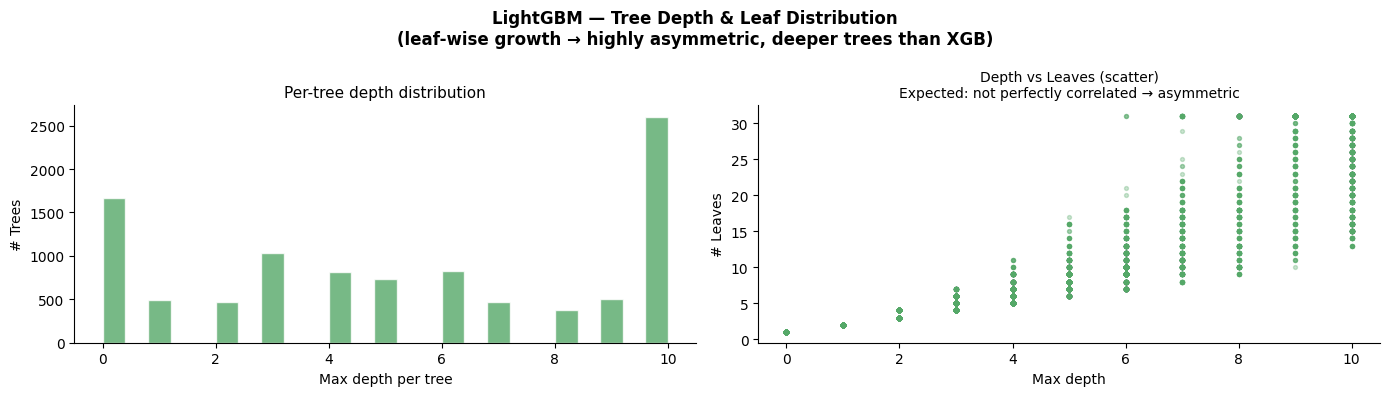


  Plotting LightGBM tree #0 (tuned model)…
  Graphviz fallback: lightgbm.plotting._to_graphviz() got multiple values for keyword argument 'feature_names'


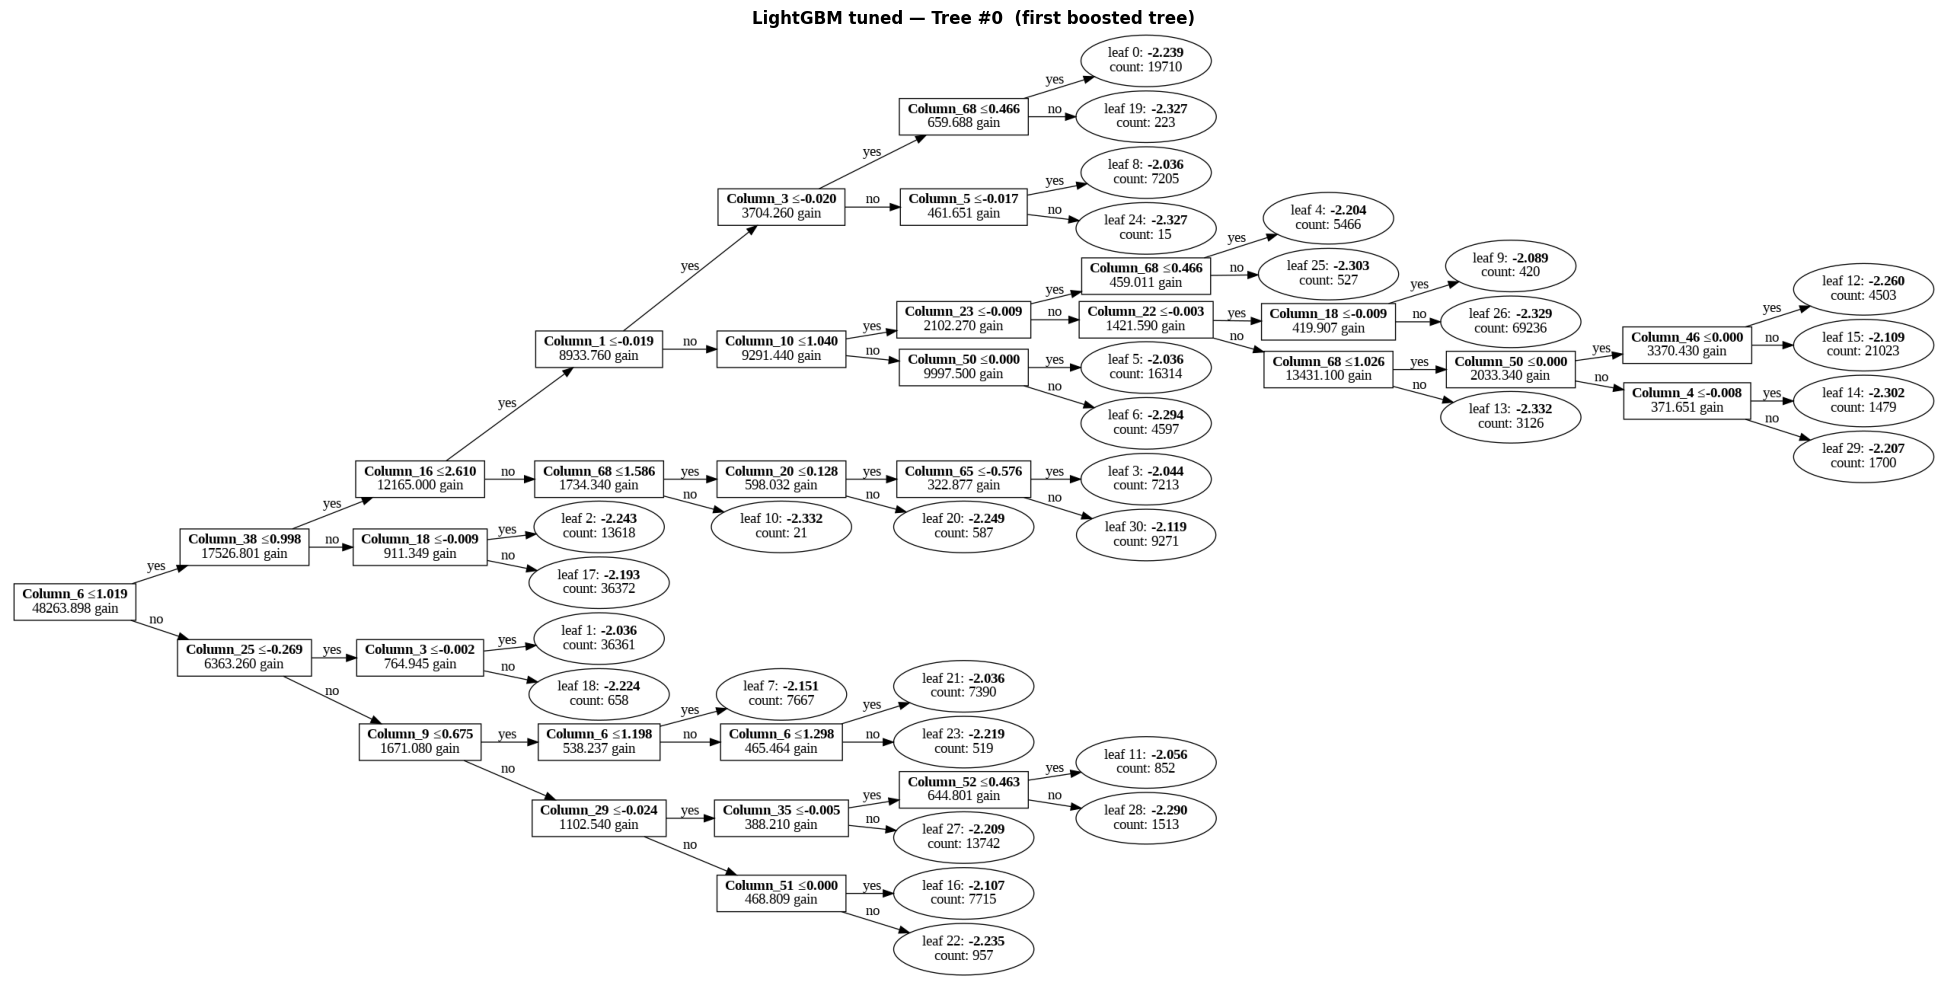


  ╔══════════════════════════════════════════════════════════════╗
  ║           LIGHTGBM  —  ARCHITECTURE SUMMARY                 ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  Type          : Gradient Boosted Trees (leaf-wise growth)   ║
  ║  Growth policy : Best-leaf-first (not level-wise like XGB)   ║
  ║                  → deeper asymmetric trees, faster to train  ║
  ║  Histogram     : Features discretised into bins (CPU)        ║
  ║  Leaf cap      : num_leaves=31 (hard cap on tree complexity) ║
  ║  Regularisation: L1 (α=0.1) + L2 (λ=1.0) + min_split_gain  ║
  ║  Imbalance fix : class_weight="balanced"                     ║
  ║                                                              ║
  ║  baseline  n_estimators=500   num_leaves=31  lr=0.05         ║
  ║  tuned     n_estimators=1000  num_leaves=31  lr=0.03         ║
  ╚══════════════════════════════════════════════════════════════╝


══════════════════════════════════════════════════════════════

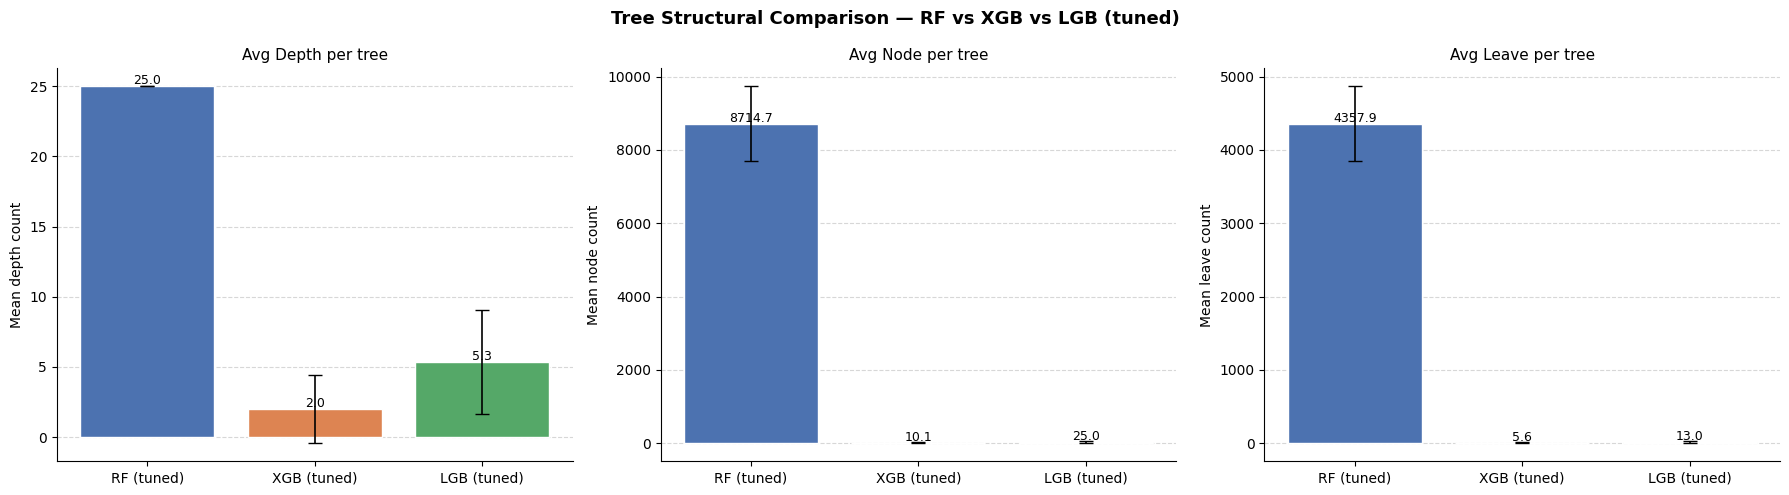

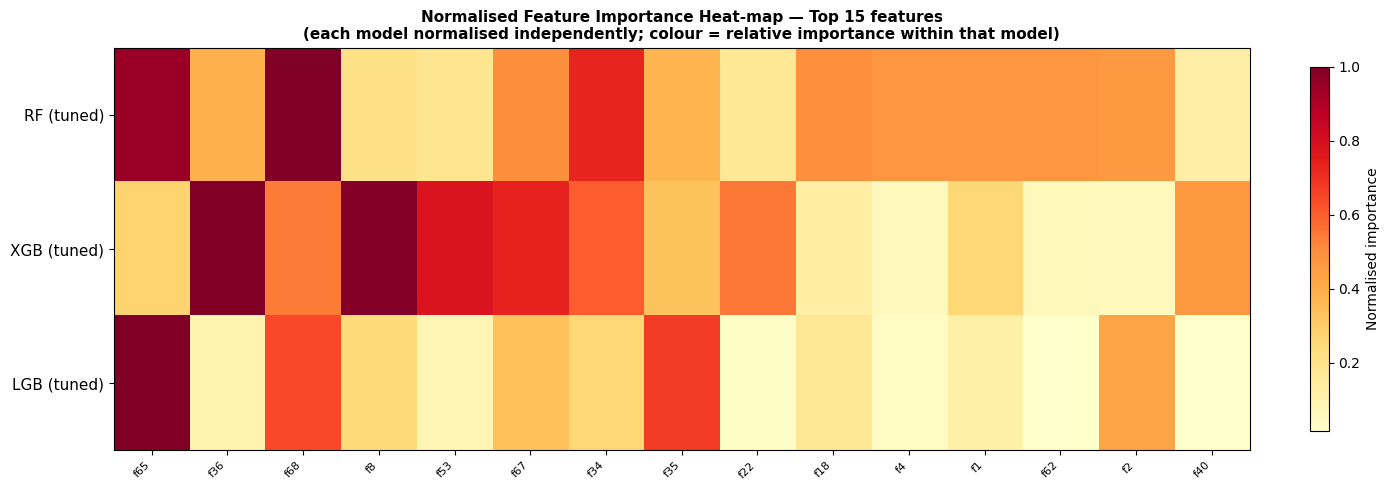


  ╔══════════════════════════╦═════════════════════╦═════════════════════╦═════════════════════╗
  ║ Attribute                ║   Random Forest     ║      XGBoost        ║      LightGBM       ║
  ╠══════════════════════════╬═════════════════════╬═════════════════════╬═════════════════════╣
  ║ Ensemble type            ║  Bagging            ║  Boosting           ║  Boosting           ║
  ║ Tree growth              ║  Level-wise (CART)  ║  Level-wise (hist)  ║  Leaf-wise (best)   ║
  ║ Trees sequential?        ║  No  (parallel)     ║  Yes                ║  Yes                ║
  ║ Each tree targets        ║  Random subset      ║  Pseudo-residuals   ║  Pseudo-residuals   ║
  ║ Depth limit              ║  max_depth          ║  max_depth          ║  num_leaves (hard)  ║
  ║ Feature subsampling      ║  √F per split       ║  colsample_bytree   ║  colsample_bytree   ║
  ║ Regularisation           ║  min_samples_leaf   ║  α, λ, γ, min_cw   ║  α, λ, min_split    ║
  ║ GPU support              ║

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
#  TREE-BASED MODEL ARCHITECTURE & STRUCTURE BLOCK
#  Covers: Random Forest  |  XGBoost  |  LightGBM  (both baseline + tuned)
#
#  Sections:
#    A. Random Forest  — sample tree plot + forest-level statistics
#    B. XGBoost        — sample tree plot + booster structure dump
#    C. LightGBM       — sample tree plot + leaf-wise growth analysis
#    D. Side-by-side comparison of all three families
#
#  Prerequisites: the cell with rf, rf2, xgb_model, xgb2, lgb_model, lgb2
#  must have been executed.  The feature names array is rebuilt here if absent.
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.tree import plot_tree, export_text
import xgboost as xgb
import lightgbm as lgb
import json, re, math, warnings
warnings.filterwarnings("ignore")

# ── Feature names (needed for readable labels) ─────────────────────────────────
# If NUM_FEATURES is set from the preprocessing cells, we build generic names.
# Replace with your actual column list if available, e.g.:
#   FEATURE_NAMES = df.drop(columns=["Label"]).select_dtypes(include=[np.number]).columns.tolist()
try:
    FEATURE_NAMES = FEATURE_NAMES   # reuse if already defined earlier in the notebook
except NameError:
    FEATURE_NAMES = [f"f{i}" for i in range(NUM_FEATURES)]

SHORT_NAMES = FEATURE_NAMES   # alias — swap with short display names if you want

SECTION = lambda t: print(f"\n{'═'*70}\n  {t}\n{'═'*70}")

# ══════════════════════════════════════════════════════════════════════════════
#  A.  RANDOM FOREST
# ══════════════════════════════════════════════════════════════════════════════
SECTION("A — RANDOM FOREST  (structure & architecture)")

# ── A1. Forest-level statistics ────────────────────────────────────────────────
def rf_forest_stats(rf_model, label="RF"):
    depths, nodes, leaves = [], [], []
    for est in rf_model.estimators_:
        t = est.tree_
        depths.append(t.max_depth)
        nodes.append(t.node_count)
        leaves.append(t.n_node_samples[t.children_left == -1].shape[0])

    print(f"\n  ── {label} forest structure ─────────────────────────────")
    print(f"  Trees           : {rf_model.n_estimators}")
    print(f"  Max features    : {rf_model.max_features}  ({rf_model.max_features} of {NUM_FEATURES})")
    print(f"  Depth  — min/avg/max : {min(depths):.0f} / {np.mean(depths):.1f} / {max(depths):.0f}")
    print(f"  Nodes  — min/avg/max : {min(nodes):.0f} / {np.mean(nodes):.1f} / {max(nodes):.0f}")
    print(f"  Leaves — min/avg/max : {min(leaves):.0f} / {np.mean(leaves):.1f} / {max(leaves):.0f}")
    print(f"  Total nodes (all trees): {sum(nodes):,}")
    return depths, nodes, leaves

depths_rf,  nodes_rf,  leaves_rf  = rf_forest_stats(rf,  "RF baseline")
depths_rf2, nodes_rf2, leaves_rf2 = rf_forest_stats(rf2, "RF tuned")

# ── A2. Feature importances (top 20) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, model, title in [
    (axes[0], rf,  "RF baseline — Feature Importances (top 20)"),
    (axes[1], rf2, "RF tuned   — Feature Importances (top 20)"),
]:
    imp   = model.feature_importances_
    top20 = np.argsort(imp)[-20:]
    ax.barh(range(20), imp[top20], color="#4C72B0", edgecolor="white", height=0.7)
    ax.set_yticks(range(20))
    ax.set_yticklabels([SHORT_NAMES[i] for i in top20], fontsize=8)
    ax.set_xlabel("Mean Decrease Impurity", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("rf_feature_importances.png", dpi=120, bbox_inches="tight")
plt.show()

# ── A3. Depth + node-count distributions across the forest ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Random Forest — Per-Tree Statistics (baseline vs tuned)",
             fontsize=13, fontweight="bold")

for metric, d1, d2, xlabel in [
    ("Depth",  depths_rf,  depths_rf2,  "Max depth per tree"),
    ("Nodes",  nodes_rf,   nodes_rf2,   "Node count per tree"),
    ("Leaves", leaves_rf,  leaves_rf2,  "Leaf count per tree"),
]:
    ax = axes[["Depth","Nodes","Leaves"].index(metric)]
    bins = 30
    ax.hist(d1, bins=bins, alpha=0.6, label="Baseline", color="#4C72B0", edgecolor="white")
    ax.hist(d2, bins=bins, alpha=0.6, label="Tuned",    color="#DD8452", edgecolor="white")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("# Trees", fontsize=10)
    ax.set_title(metric, fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("rf_tree_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

# ── A4. Single tree visualisation (shallow truncation for readability) ─────────
#  We pick the shallowest estimator so the plot isn't a wall of nodes.
shallowest_idx = int(np.argmin([e.tree_.max_depth for e in rf2.estimators_]))
shallow_tree   = rf2.estimators_[shallowest_idx]

print(f"\n  Visualising tree #{shallowest_idx} from RF-tuned  "
      f"(depth={shallow_tree.tree_.max_depth}, nodes={shallow_tree.tree_.node_count})")
print(f"  (truncated to max_depth=4 for readability)\n")
print(export_text(shallow_tree, feature_names=SHORT_NAMES, max_depth=3))

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    shallow_tree,
    feature_names=SHORT_NAMES,
    class_names=le2.classes_,
    max_depth=4,
    filled=True,
    rounded=True,
    fontsize=7,
    ax=ax,
    impurity=True,
    proportion=False,
)
ax.set_title(
    f"RF tuned — Tree #{shallowest_idx}  |  depth={shallow_tree.tree_.max_depth}  "
    f"(display truncated to depth 4)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("rf_single_tree.png", dpi=100, bbox_inches="tight")
plt.show()

# ── A5. Architecture summary box ──────────────────────────────────────────────
print("""
  ╔══════════════════════════════════════════════════════════════╗
  ║          RANDOM FOREST  —  ARCHITECTURE SUMMARY             ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  Type          : Bagging ensemble of CART decision trees     ║
  ║  Training      : Each tree on a bootstrap sample of data     ║
  ║                  Each split considers √F random features      ║
  ║  Prediction    : Majority vote across all T trees            ║
  ║  Depth control : max_depth=25 (tuned) prevents overfit       ║
  ║  Imbalance fix : balanced_subsample class weighting          ║
  ║  Parallelism   : All trees built independently → n_jobs=-1   ║
  ║                                                              ║
  ║  baseline  n_estimators=200  max_depth=20  leaf=4            ║
  ║  tuned     n_estimators=300  max_depth=25  leaf=2            ║
  ╚══════════════════════════════════════════════════════════════╝
""")

# ══════════════════════════════════════════════════════════════════════════════
#  B.  XGBOOST
# ══════════════════════════════════════════════════════════════════════════════
SECTION("B — XGBOOST  (structure & architecture)")

# ── B1. Booster-level statistics from the dump ────────────────────────────────
def xgb_booster_stats(model, label="XGB"):
    booster   = model.get_booster()
    raw_dump  = booster.get_dump(with_stats=True)  # one string per tree
    depths_list, nodes_list, leaves_list, gain_list = [], [], [], []

    for tree_str in raw_dump:
        lines  = tree_str.strip().split("\n")
        max_d  = 0
        n_nodes, n_leaves = 0, 0
        gains  = []
        for line in lines:
            n_nodes += 1
            depth = len(line) - len(line.lstrip("\t"))
            max_d = max(max_d, depth)
            if "leaf" in line:
                n_leaves += 1
            g = re.search(r"gain=([0-9.]+)", line)
            if g:
                gains.append(float(g.group(1)))
        depths_list.append(max_d)
        nodes_list.append(n_nodes)
        leaves_list.append(n_leaves)
        gain_list.append(np.mean(gains) if gains else 0)

    actual_T = len(raw_dump)
    print(f"\n  ── {label} booster structure ─────────────────────────────")
    print(f"  Trees (actual) : {actual_T}")
    print(f"  Max depth      : {model.max_depth}")
    print(f"  Depth  — min/avg/max : {min(depths_list):.0f} / {np.mean(depths_list):.1f} / {max(depths_list):.0f}")
    print(f"  Nodes  — min/avg/max : {min(nodes_list):.0f} / {np.mean(nodes_list):.1f} / {max(nodes_list):.0f}")
    print(f"  Leaves — min/avg/max : {min(leaves_list):.0f} / {np.mean(leaves_list):.1f} / {max(leaves_list):.0f}")
    print(f"  Avg split gain (early trees vs late):")
    q = actual_T // 4
    print(f"    First 25%: {np.mean(gain_list[:q]):.4f}   |   Last 25%: {np.mean(gain_list[-q:]):.4f}")
    print(f"    (Gain decay = expected boosting convergence behaviour)")
    return depths_list, nodes_list, leaves_list, gain_list

depths_xgb,  nodes_xgb,  leaves_xgb,  gain_xgb  = xgb_booster_stats(xgb_model, "XGB baseline")
depths_xgb2, nodes_xgb2, leaves_xgb2, gain_xgb2 = xgb_booster_stats(xgb2,      "XGB tuned")

# ── B2. Feature importances (weight / gain / cover) ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("XGBoost (tuned) — Feature Importance by different metrics",
             fontsize=13, fontweight="bold")

for ax, imp_type, color in [
    (axes[0], "weight", "#4C72B0"),
    (axes[1], "gain",   "#DD8452"),
    (axes[2], "cover",  "#55A868"),
]:
    scores = xgb2.get_booster().get_score(importance_type=imp_type)
    if not scores:
        ax.set_title(f"{imp_type} (unavailable)"); continue
    df_imp  = pd.Series(scores).sort_values(ascending=False).head(20)
    # Map f0, f1 … back to feature names
    renamed = {f"f{i}": n for i, n in enumerate(SHORT_NAMES)}
    df_imp.index = [renamed.get(k, k) for k in df_imp.index]
    ax.barh(df_imp.index[::-1], df_imp.values[::-1], color=color, edgecolor="white", height=0.7)
    ax.set_title(f"Importance type: {imp_type}", fontsize=11)
    ax.set_xlabel(imp_type.capitalize(), fontsize=10)
    ax.spines[["top","right"]].set_visible(False)
    ax.xaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("xgb_feature_importances.png", dpi=120, bbox_inches="tight")
plt.show()

# ── B3. Gain decay curve across boosting rounds ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
window = 10
smooth = lambda g: np.convolve(g, np.ones(window)/window, mode="valid")
ax.plot(smooth(gain_xgb),  label="Baseline", color="#4C72B0", linewidth=1.5)
ax.plot(smooth(gain_xgb2), label="Tuned",    color="#DD8452", linewidth=1.5)
ax.set_xlabel("Boosting round", fontsize=11)
ax.set_ylabel("Mean split gain (smoothed)", fontsize=11)
ax.set_title("XGBoost — Split gain decay across boosting rounds\n"
             "(early rounds learn fast; later rounds refine residuals)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("xgb_gain_decay.png", dpi=120, bbox_inches="tight")
plt.show()

# ── B4. Single tree plot (tree 0 of tuned XGB) ────────────────────────────────
print("\n  Plotting XGBoost tree #0 (tuned model)…")
fig, ax = plt.subplots(figsize=(22, 10))
xgb.plot_tree(xgb2, num_trees=0, ax=ax, rankdir="LR")
ax.set_title("XGBoost tuned — Tree #0  (first boosted tree)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("xgb_single_tree.png", dpi=100, bbox_inches="tight")
plt.show()

# ── B5. Architecture summary box ──────────────────────────────────────────────
print("""
  ╔══════════════════════════════════════════════════════════════╗
  ║            XGBOOST  —  ARCHITECTURE SUMMARY                 ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  Type          : Gradient Boosted Trees (level-wise growth)  ║
  ║  Training      : Sequential; tree t fixes residuals of t-1   ║
  ║  Loss          : Multiclass log-loss (mlogloss)              ║
  ║  Tree growth   : Level-wise (breadth-first) via hist method  ║
  ║  Regularisation: L1 (α=0.5) + L2 (λ=3.0) + γ=2.0 min gain  ║
  ║  Imbalance fix : Per-sample capped weights (20× max ratio)   ║
  ║  Hardware      : CUDA histogram builder (GPU)                ║
  ║                                                              ║
  ║  baseline  n_estimators=500  max_depth=6  lr=0.05            ║
  ║  tuned     early-stopped     max_depth=6  lr=0.05            ║
  ╚══════════════════════════════════════════════════════════════╝
""")

# ══════════════════════════════════════════════════════════════════════════════
#  C.  LIGHTGBM
# ══════════════════════════════════════════════════════════════════════════════
SECTION("C — LIGHTGBM  (structure & architecture)")

# ── C1. Booster-level statistics via dump_model ────────────────────────────────
def lgb_booster_stats(model, label="LGB"):
    dump    = model.booster_.dump_model()
    trees   = dump.get("tree_info", [])

    depths_list, leaves_list, nodes_list = [], [], []

    def walk(node, depth=0):
        if "leaf_value" in node:       # leaf node
            return depth, 1, 1        # (max_depth_from_here, leaf_count, node_count)
        ld, ll, ln = walk(node["left_child"],  depth + 1)
        rd, rl, rn = walk(node["right_child"], depth + 1)
        return max(ld, rd), ll + rl, ln + rn + 1

    for tree_info in trees:
        root = tree_info.get("tree_structure", {})
        if not root:
            continue
        d, l, n = walk(root)
        depths_list.append(d)
        leaves_list.append(l)
        nodes_list.append(n)

    print(f"\n  ── {label} booster structure ─────────────────────────────")
    print(f"  Trees (actual) : {len(trees)}")
    print(f"  Num leaves     : {model.num_leaves}  (hard cap — leaf-wise growth)")
    print(f"  Depth  — min/avg/max : {min(depths_list):.0f} / {np.mean(depths_list):.1f} / {max(depths_list):.0f}")
    print(f"  Leaves — min/avg/max : {min(leaves_list):.0f} / {np.mean(leaves_list):.1f} / {max(leaves_list):.0f}")
    print(f"  Nodes  — min/avg/max : {min(nodes_list):.0f} / {np.mean(nodes_list):.1f} / {max(nodes_list):.0f}")
    print(f"  Note: LightGBM splits the leaf with the highest gain at each step,")
    print(f"        not the whole level → trees are deeper and more asymmetric than XGB.")
    return depths_list, leaves_list, nodes_list

depths_lgb,  leaves_lgb,  nodes_lgb  = lgb_booster_stats(lgb_model, "LGB baseline")
depths_lgb2, leaves_lgb2, nodes_lgb2 = lgb_booster_stats(lgb2,      "LGB tuned")

# ── C2. Feature importances (split count and gain) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("LightGBM (tuned) — Feature Importance (top 20)",
             fontsize=13, fontweight="bold")

for ax, imp_type, color in [
    (axes[0], "split", "#4C72B0"),
    (axes[1], "gain",  "#55A868"),
]:
    imp  = lgb2.booster_.feature_importance(importance_type=imp_type)
    top  = np.argsort(imp)[-20:]
    ax.barh(range(20), imp[top], color=color, edgecolor="white", height=0.7)
    ax.set_yticks(range(20))
    ax.set_yticklabels([SHORT_NAMES[i] for i in top], fontsize=8)
    ax.set_xlabel(f"Importance ({imp_type})", fontsize=10)
    ax.set_title(f"{imp_type.capitalize()} importance", fontsize=11)
    ax.spines[["top","right"]].set_visible(False)
    ax.xaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("lgb_feature_importances.png", dpi=120, bbox_inches="tight")
plt.show()

# ── C3. Tree depth distribution — leaf-wise asymmetry ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("LightGBM — Tree Depth & Leaf Distribution\n"
             "(leaf-wise growth → highly asymmetric, deeper trees than XGB)",
             fontsize=12, fontweight="bold")

for ax, d, l, label, color in [
    (axes[0], depths_lgb2, leaves_lgb2, "Tuned",    "#55A868"),
]:
    ax.hist(d, bins=25, alpha=0.8, color=color, edgecolor="white", label="Depth")
    ax.set_xlabel("Max depth per tree", fontsize=10)
    ax.set_ylabel("# Trees", fontsize=10)
    ax.set_title("Per-tree depth distribution", fontsize=11)
    ax.spines[["top","right"]].set_visible(False)

ax2 = axes[1]
ax2.scatter(depths_lgb2, leaves_lgb2, alpha=0.3, s=8, color="#55A868")
ax2.set_xlabel("Max depth", fontsize=10)
ax2.set_ylabel("# Leaves", fontsize=10)
ax2.set_title("Depth vs Leaves (scatter)\nExpected: not perfectly correlated → asymmetric", fontsize=10)
ax2.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("lgb_tree_depth_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

# ── C4. Single tree via create_tree_digraph ────────────────────────────────────
print("\n  Plotting LightGBM tree #0 (tuned model)…")
try:
    graph = lgb.create_tree_digraph(lgb2, tree_index=0,
                                    feature_names=SHORT_NAMES,
                                    show_info=["split_gain", "internal_value",
                                               "internal_count", "leaf_count"])
    graph.render("lgb_single_tree", format="png", cleanup=True)
    print("  Saved to lgb_single_tree.png")
    from IPython.display import Image
    display(Image("lgb_single_tree.png"))
except Exception as e:
    # Fallback: matplotlib version
    print(f"  Graphviz fallback: {e}")
    fig, ax = plt.subplots(figsize=(22, 10))
    lgb.plot_tree(lgb2, tree_index=0, ax=ax,
                  show_info=["split_gain", "leaf_count"])
    ax.set_title("LightGBM tuned — Tree #0  (first boosted tree)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("lgb_single_tree.png", dpi=100, bbox_inches="tight")
    plt.show()

# ── C5. Architecture summary box ──────────────────────────────────────────────
print("""
  ╔══════════════════════════════════════════════════════════════╗
  ║           LIGHTGBM  —  ARCHITECTURE SUMMARY                 ║
  ╠══════════════════════════════════════════════════════════════╣
  ║  Type          : Gradient Boosted Trees (leaf-wise growth)   ║
  ║  Growth policy : Best-leaf-first (not level-wise like XGB)   ║
  ║                  → deeper asymmetric trees, faster to train  ║
  ║  Histogram     : Features discretised into bins (CPU)        ║
  ║  Leaf cap      : num_leaves=31 (hard cap on tree complexity) ║
  ║  Regularisation: L1 (α=0.1) + L2 (λ=1.0) + min_split_gain  ║
  ║  Imbalance fix : class_weight="balanced"                     ║
  ║                                                              ║
  ║  baseline  n_estimators=500   num_leaves=31  lr=0.05         ║
  ║  tuned     n_estimators=1000  num_leaves=31  lr=0.03         ║
  ╚══════════════════════════════════════════════════════════════╝
""")

# ══════════════════════════════════════════════════════════════════════════════
#  D.  SIDE-BY-SIDE COMPARISON — all three families
# ══════════════════════════════════════════════════════════════════════════════
SECTION("D — SIDE-BY-SIDE TREE FAMILY COMPARISON")

# ── D1. Depth / Nodes / Leaves comparison bars ────────────────────────────────
families = {
    "RF (tuned)"    : {"depths": depths_rf2,  "nodes": nodes_rf2,   "leaves": leaves_rf2,  "color": "#4C72B0"},
    "XGB (tuned)"   : {"depths": depths_xgb2, "nodes": nodes_xgb2,  "leaves": leaves_xgb2, "color": "#DD8452"},
    "LGB (tuned)"   : {"depths": depths_lgb2, "nodes": nodes_lgb2,  "leaves": leaves_lgb2, "color": "#55A868"},
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Tree Structural Comparison — RF vs XGB vs LGB (tuned)",
             fontsize=13, fontweight="bold")

for ax, metric in zip(axes, ["depths", "nodes", "leaves"]):
    names  = list(families.keys())
    means  = [np.mean(families[n][metric]) for n in names]
    stds   = [np.std( families[n][metric]) for n in names]
    colors = [families[n]["color"]         for n in names]
    bars   = ax.bar(names, means, color=colors, edgecolor="white",
                    yerr=stds, capsize=5, error_kw={"linewidth":1.2})
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(stds)*0.05,
                f"{val:.1f}", ha="center", fontsize=9)
    ax.set_title(f"Avg {metric.capitalize()[:-1]} per tree", fontsize=11)
    ax.set_ylabel(f"Mean {metric[:-1]} count", fontsize=10)
    ax.spines[["top","right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("tree_family_comparison_structure.png", dpi=120, bbox_inches="tight")
plt.show()

# ── D2. Shared feature importance heat-map (top 15 features) ──────────────────
top_k = 15
rf_imp  = rf2.feature_importances_
xgb_raw = xgb2.get_booster().get_score(importance_type="gain")
xgb_imp = np.zeros(NUM_FEATURES)
for k, v in xgb_raw.items():
    idx = int(k[1:]) if k.startswith("f") else SHORT_NAMES.index(k)
    xgb_imp[idx] = v

lgb_imp = lgb2.booster_.feature_importance(importance_type="gain")

# Normalise each to [0, 1]
def norm(arr): return arr / (arr.max() + 1e-9)

matrix   = np.stack([norm(rf_imp), norm(xgb_imp), norm(lgb_imp)], axis=0)
top_idx  = np.argsort(matrix.max(axis=0))[-top_k:][::-1]
heat_mat = matrix[:, top_idx]

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heat_mat, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(top_k))
ax.set_xticklabels([SHORT_NAMES[i] for i in top_idx], rotation=45, ha="right", fontsize=8)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["RF (tuned)", "XGB (tuned)", "LGB (tuned)"], fontsize=11)
ax.set_title(f"Normalised Feature Importance Heat-map — Top {top_k} features\n"
             f"(each model normalised independently; colour = relative importance within that model)",
             fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.015, label="Normalised importance")
plt.tight_layout()
plt.savefig("tree_feature_importance_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

# ── D3. Conceptual architecture comparison table ──────────────────────────────
print("""
  ╔══════════════════════════╦═════════════════════╦═════════════════════╦═════════════════════╗
  ║ Attribute                ║   Random Forest     ║      XGBoost        ║      LightGBM       ║
  ╠══════════════════════════╬═════════════════════╬═════════════════════╬═════════════════════╣
  ║ Ensemble type            ║  Bagging            ║  Boosting           ║  Boosting           ║
  ║ Tree growth              ║  Level-wise (CART)  ║  Level-wise (hist)  ║  Leaf-wise (best)   ║
  ║ Trees sequential?        ║  No  (parallel)     ║  Yes                ║  Yes                ║
  ║ Each tree targets        ║  Random subset      ║  Pseudo-residuals   ║  Pseudo-residuals   ║
  ║ Depth limit              ║  max_depth          ║  max_depth          ║  num_leaves (hard)  ║
  ║ Feature subsampling      ║  √F per split       ║  colsample_bytree   ║  colsample_bytree   ║
  ║ Regularisation           ║  min_samples_leaf   ║  α, λ, γ, min_cw   ║  α, λ, min_split    ║
  ║ GPU support              ║  No                 ║  Yes (hist/cuda)    ║  Optional           ║
  ║ Missing value handling   ║  Impute first        ║  Native (default)   ║  Native             ║
  ║ Typical n_trees needed   ║  200–500            ║  300–1000           ║  500–3000           ║
  ║ Interpretability/tree    ║  Full sklearn API   ║  plot_tree          ║  create_tree_digraph║
  ╚══════════════════════════╩═════════════════════╩═════════════════════╩═════════════════════╝
""")

print("  All plots saved:")
plots = [
    "rf_feature_importances.png",
    "rf_tree_distributions.png",
    "rf_single_tree.png",
    "xgb_feature_importances.png",
    "xgb_gain_decay.png",
    "xgb_single_tree.png",
    "lgb_feature_importances.png",
    "lgb_tree_depth_scatter.png",
    "lgb_single_tree.png",
    "tree_family_comparison_structure.png",
    "tree_feature_importance_heatmap.png",
]
for p in plots:
    print(f"    • {p}")

# final peiece of code, overall details in a big table:


════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  FULL MODEL SUMMARY — Architecture & Complexity
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
                   Model       Family                                                                                                                                                                   Architecture                                                     Train O(·)                                                                                   Train (numbers)                                             Infer O(·)                                  Infer (numbers)                                       Params/Trees
Random Forest (baseline) Classical ML                                                                                            Bagging ensemble | 200 CART trees | max_depth=20, 

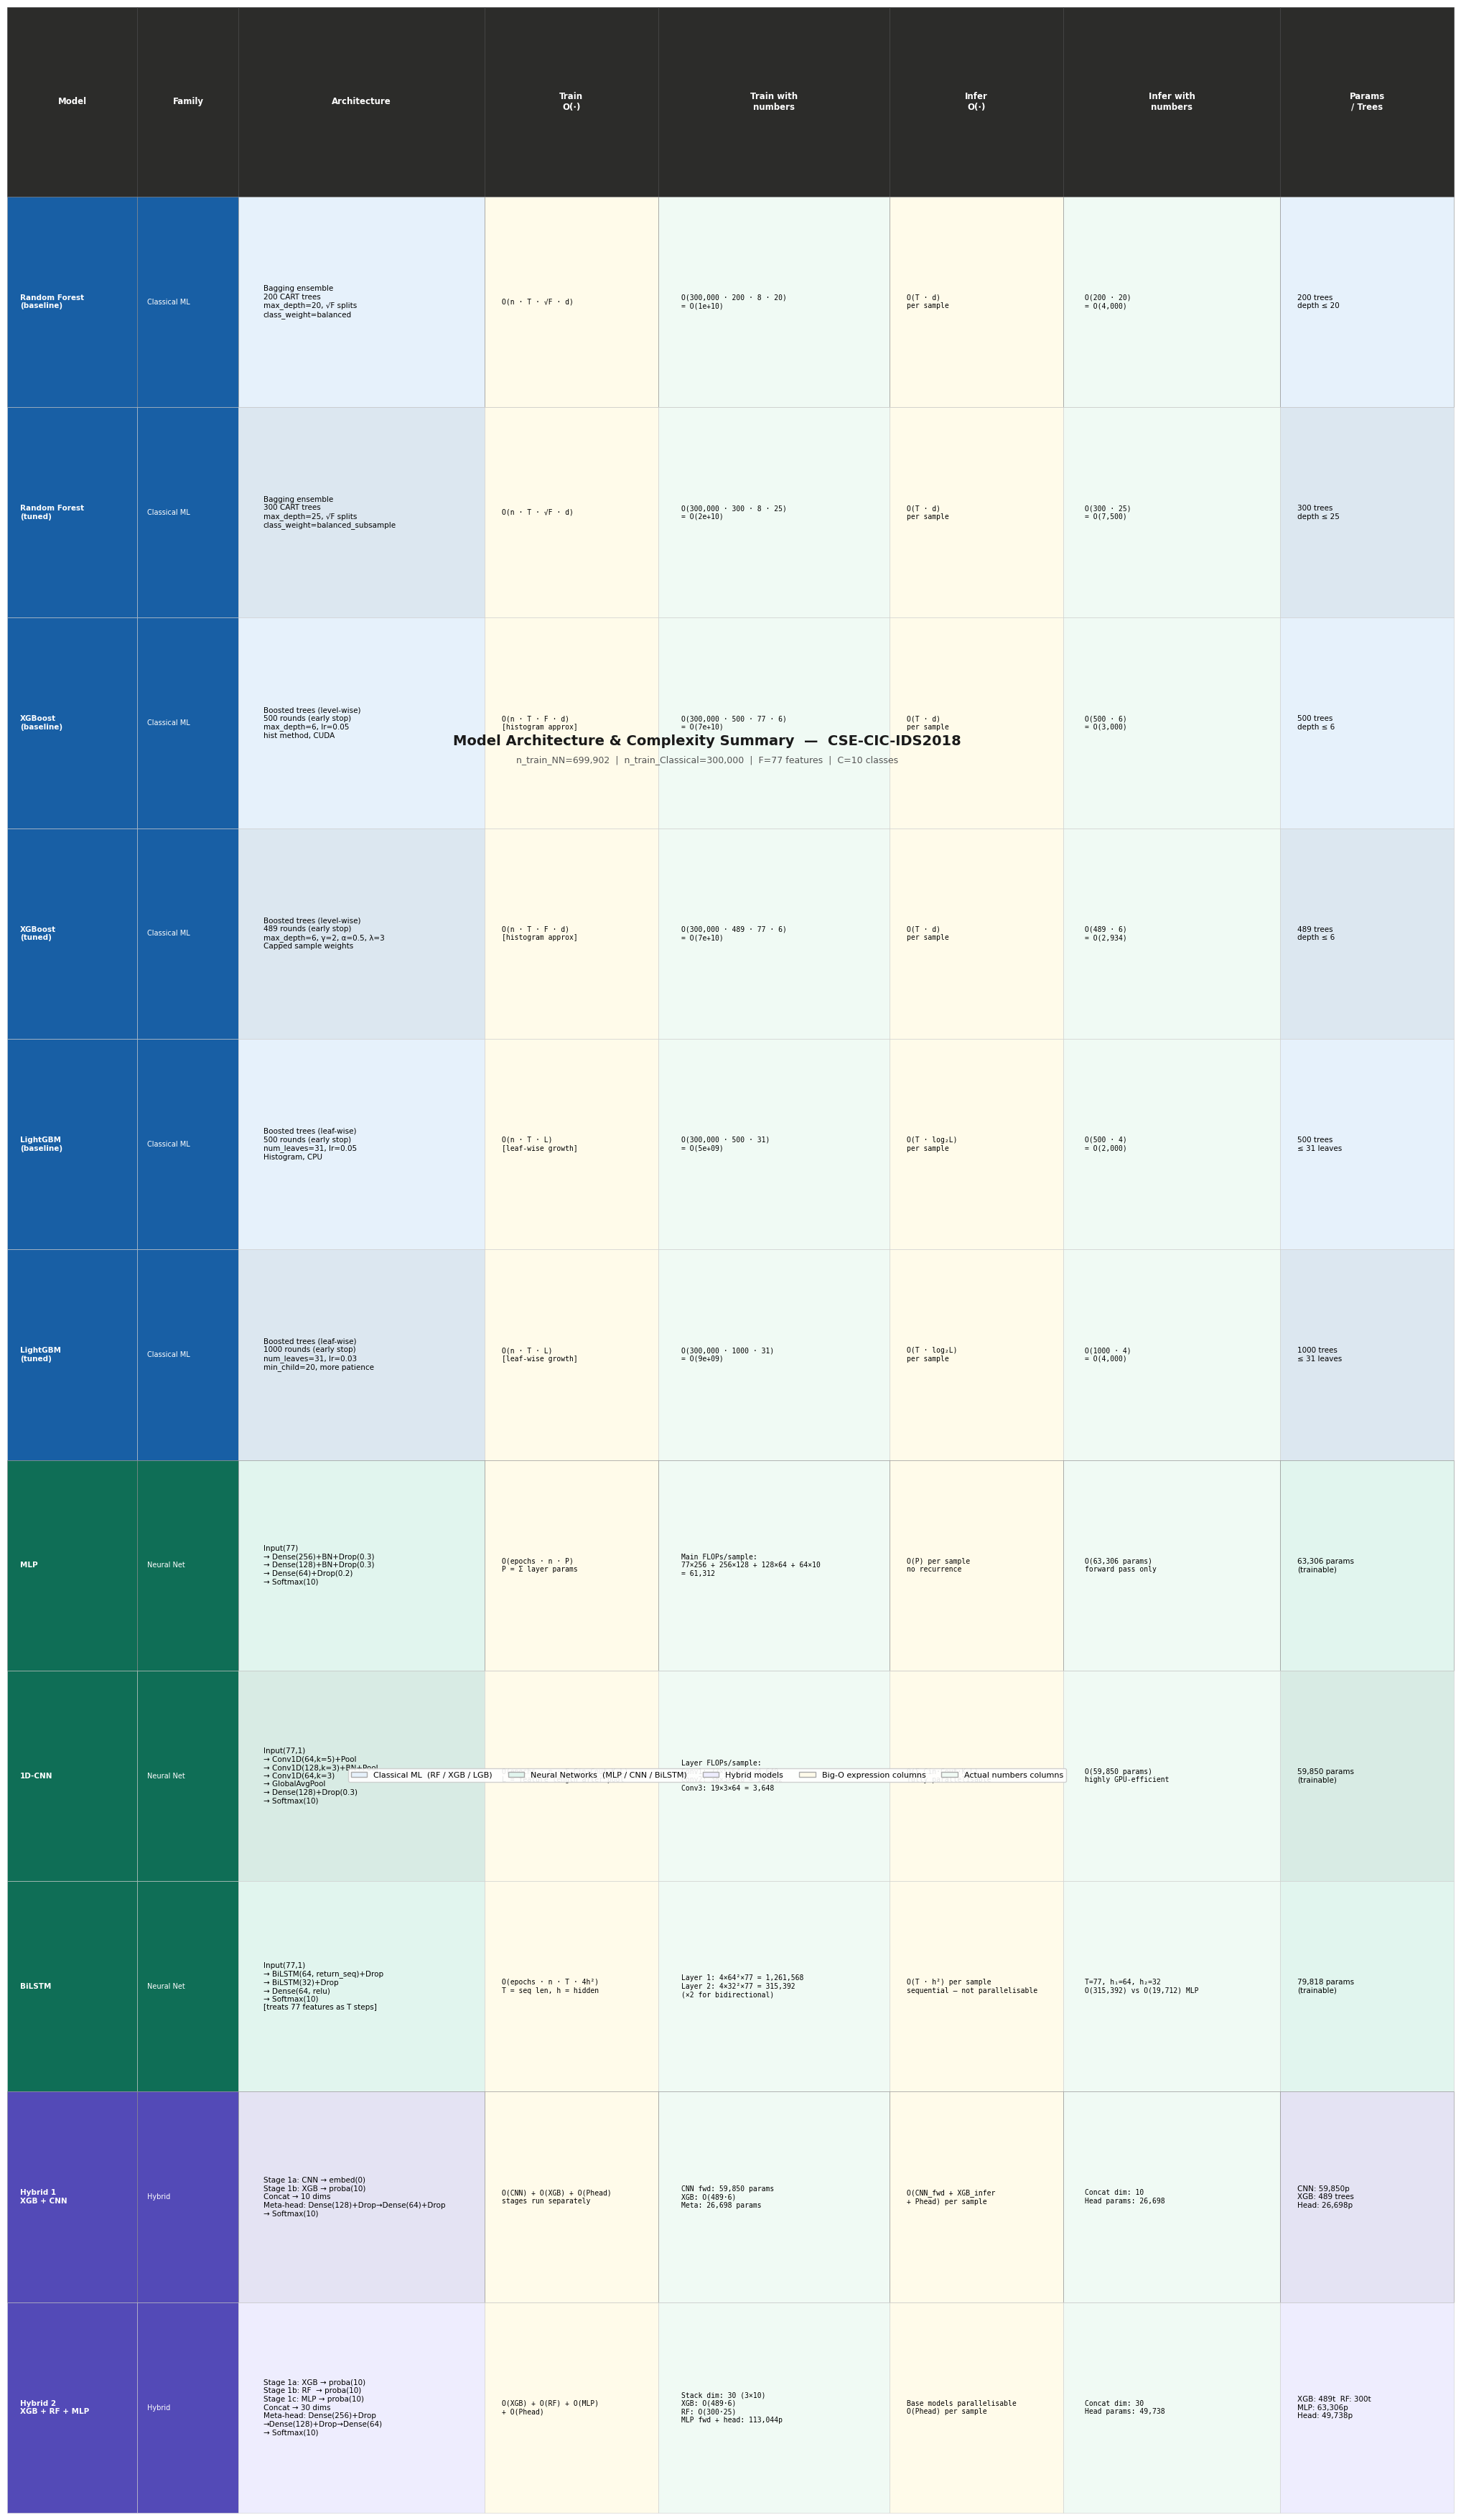

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
#  UNIFIED MODEL SUMMARY TABLE
#  Prints a terminal table + saves a high-resolution matplotlib figure.
#
#  Columns: Model | Family | Architecture | Train O(·) | Train (numbers)
#           | Infer O(·) | Infer (numbers) | Params / Trees
#
#  Prerequisites: all training cells must have been run so that
#  rf, rf2, xgb_model, xgb2, lgb_model, lgb2,
#  mlp_model, cnn_model, lstm_model, hybrid1, hybrid2  are live.
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import math, re

rcParams["font.family"] = "DejaVu Sans"   # use whatever monospace is available

# ── 0. Pull actual numbers from trained models ─────────────────────────────────
F  = NUM_FEATURES
C  = NUM_CLASSES_2
n_nn  = len(X_tr2)          # samples used for NN training
n_cl  = 300_000             # samples used for classical ML training

# RF
rf_T   = rf.n_estimators;    rf_d   = rf.max_depth
rf2_T  = rf2.n_estimators;   rf2_d  = rf2.max_depth
sqF    = int(math.sqrt(F))

# XGB
xgb_T  = xgb_model.best_iteration + 1;  xgb_d  = xgb_model.max_depth
xgb2_T = xgb2.best_iteration + 1;       xgb2_d = xgb2.max_depth

# LGB
lgb_T  = lgb_model.n_estimators_;   lgb_L  = lgb_model.num_leaves
lgb2_T = lgb2.n_estimators_;        lgb2_L = lgb2.num_leaves

# NN params
mlp_P   = mlp_model.count_params()
cnn_P   = cnn_model.count_params()
lstm_P  = lstm_model.count_params()
h1_P    = hybrid1.count_params()
h2_P    = hybrid2.count_params()

# LSTM hidden dims (read from layer names)
lstm_h1 = 64    # BiLSTM layer 1 hidden
lstm_h2 = 32    # BiLSTM layer 2 hidden

# ── 1. Build the data rows ─────────────────────────────────────────────────────
#  Each row: (model, family, architecture, train_big_o, train_numbers,
#             infer_big_o, infer_numbers, params_or_trees)

def embed_dim(model):
    """Return output dim of the last non-output layer that has output_shape."""
    for layer in reversed(model.layers[:-1]):   # skip final Dense/softmax
        try:
            shape = layer.output_shape
            # shape is (batch, units) for Dense, (batch, t, units) for recurrent
            return shape[-1]
        except AttributeError:
            continue   # Dropout, etc. — no output_shape, skip
    return 0

cnn_embed  = embed_dim(cnn_model)
lstm_embed = embed_dim(lstm_model)
mlp_embed  = embed_dim(mlp_model)

rows = [
    # ── Classical ML ────────────────────────────────────────────────────────
    (
        "Random Forest\n(baseline)",
        "Classical ML",
        f"Bagging ensemble\n{rf_T} CART trees\nmax_depth={rf_d}, √F splits\nclass_weight=balanced",
        "O(n · T · √F · d)",
        f"O({n_cl:,} · {rf_T} · {sqF} · {rf_d})\n= O({n_cl*rf_T*sqF*rf_d:,.0e})",
        "O(T · d)\nper sample",
        f"O({rf_T} · {rf_d})\n= O({rf_T*rf_d:,})",
        f"{rf_T} trees\ndepth ≤ {rf_d}",
    ),
    (
        "Random Forest\n(tuned)",
        "Classical ML",
        f"Bagging ensemble\n{rf2_T} CART trees\nmax_depth={rf2_d}, √F splits\nclass_weight=balanced_subsample",
        "O(n · T · √F · d)",
        f"O({n_cl:,} · {rf2_T} · {sqF} · {rf2_d})\n= O({n_cl*rf2_T*sqF*rf2_d:,.0e})",
        "O(T · d)\nper sample",
        f"O({rf2_T} · {rf2_d})\n= O({rf2_T*rf2_d:,})",
        f"{rf2_T} trees\ndepth ≤ {rf2_d}",
    ),
    (
        "XGBoost\n(baseline)",
        "Classical ML",
        f"Boosted trees (level-wise)\n{xgb_T} rounds (early stop)\nmax_depth={xgb_d}, lr=0.05\nhist method, CUDA",
        "O(n · T · F · d)\n[histogram approx]",
        f"O({n_cl:,} · {xgb_T} · {F} · {xgb_d})\n= O({n_cl*xgb_T*F*xgb_d:,.0e})",
        "O(T · d)\nper sample",
        f"O({xgb_T} · {xgb_d})\n= O({xgb_T*xgb_d:,})",
        f"{xgb_T} trees\ndepth ≤ {xgb_d}",
    ),
    (
        "XGBoost\n(tuned)",
        "Classical ML",
        f"Boosted trees (level-wise)\n{xgb2_T} rounds (early stop)\nmax_depth={xgb2_d}, γ=2, α=0.5, λ=3\nCapped sample weights",
        "O(n · T · F · d)\n[histogram approx]",
        f"O({n_cl:,} · {xgb2_T} · {F} · {xgb2_d})\n= O({n_cl*xgb2_T*F*xgb2_d:,.0e})",
        "O(T · d)\nper sample",
        f"O({xgb2_T} · {xgb2_d})\n= O({xgb2_T*xgb2_d:,})",
        f"{xgb2_T} trees\ndepth ≤ {xgb2_d}",
    ),
    (
        "LightGBM\n(baseline)",
        "Classical ML",
        f"Boosted trees (leaf-wise)\n{lgb_T} rounds (early stop)\nnum_leaves={lgb_L}, lr=0.05\nHistogram, CPU",
        "O(n · T · L)\n[leaf-wise growth]",
        f"O({n_cl:,} · {lgb_T} · {lgb_L})\n= O({n_cl*lgb_T*lgb_L:,.0e})",
        "O(T · log₂L)\nper sample",
        f"O({lgb_T} · {int(math.log2(lgb_L))})\n= O({lgb_T*int(math.log2(lgb_L)):,})",
        f"{lgb_T} trees\n≤ {lgb_L} leaves",
    ),
    (
        "LightGBM\n(tuned)",
        "Classical ML",
        f"Boosted trees (leaf-wise)\n{lgb2_T} rounds (early stop)\nnum_leaves={lgb2_L}, lr=0.03\nmin_child=20, more patience",
        "O(n · T · L)\n[leaf-wise growth]",
        f"O({n_cl:,} · {lgb2_T} · {lgb2_L})\n= O({n_cl*lgb2_T*lgb2_L:,.0e})",
        "O(T · log₂L)\nper sample",
        f"O({lgb2_T} · {int(math.log2(lgb2_L))})\n= O({lgb2_T*int(math.log2(lgb2_L)):,})",
        f"{lgb2_T} trees\n≤ {lgb2_L} leaves",
    ),

    # ── Neural Networks ──────────────────────────────────────────────────────
    (
        "MLP",
        "Neural Net",
        f"Input({F})\n→ Dense(256)+BN+Drop(0.3)\n→ Dense(128)+BN+Drop(0.3)\n→ Dense(64)+Drop(0.2)\n→ Softmax({C})",
        "O(epochs · n · P)\nP = Σ layer params",
        f"Main FLOPs/sample:\n{F}×256 + 256×128 + 128×64 + 64×{C}\n= {F*256+256*128+128*64+64*C:,}",
        "O(P) per sample\nno recurrence",
        f"O({mlp_P:,} params)\nforward pass only",
        f"{mlp_P:,} params\n(trainable)",
    ),
    (
        "1D-CNN",
        "Neural Net",
        f"Input({F},1)\n→ Conv1D(64,k=5)+Pool\n→ Conv1D(128,k=3)+BN+Pool\n→ Conv1D(64,k=3)\n→ GlobalAvgPool\n→ Dense(128)+Drop(0.3)\n→ Softmax({C})",
        "O(epochs · n · Σ Cin·Cout·K·L)\nL = feature length after pool",
        f"Layer FLOPs/sample:\nConv1: {F}×5×64 = {F*5*64:,}\nConv2: {F//2}×3×128 = {(F//2)*3*128:,}\nConv3: {F//4}×3×64 = {(F//4)*3*64:,}",
        "O(Σ Cin·Cout·K·L)\nfully parallelisable",
        f"O({cnn_P:,} params)\nhighly GPU-efficient",
        f"{cnn_P:,} params\n(trainable)",
    ),
    (
        "BiLSTM",
        "Neural Net",
        f"Input({F},1)\n→ BiLSTM(64, return_seq)+Drop\n→ BiLSTM(32)+Drop\n→ Dense(64, relu)\n→ Softmax({C})\n[treats {F} features as T steps]",
        "O(epochs · n · T · 4h²)\nT = seq len, h = hidden",
        f"Layer 1: 4×{lstm_h1}²×{F} = {4*lstm_h1**2*F:,}\nLayer 2: 4×{lstm_h2}²×{F} = {4*lstm_h2**2*F:,}\n(×2 for bidirectional)",
        "O(T · h²) per sample\nsequential — not parallelisable",
        f"T={F}, h₁={lstm_h1}, h₂={lstm_h2}\nO({F*lstm_h1**2:,}) vs O({F*256:,}) MLP",
        f"{lstm_P:,} params\n(trainable)",
    ),

    # ── Hybrids ──────────────────────────────────────────────────────────────
    (
        "Hybrid 1\nXGB + CNN",
        "Hybrid",
        f"Stage 1a: CNN → embed({cnn_embed})\nStage 1b: XGB → proba({C})\nConcat → {cnn_embed+C} dims\nMeta-head: Dense(128)+Drop→Dense(64)+Drop\n→ Softmax({C})",
        "O(CNN) + O(XGB) + O(Phead)\nstages run separately",
        f"CNN fwd: {cnn_P:,} params\nXGB: O({xgb2_T}·{xgb2_d})\nMeta: {h1_P:,} params",
        "O(CNN_fwd + XGB_infer\n+ Phead) per sample",
        f"Concat dim: {cnn_embed+C}\nHead params: {h1_P:,}",
        f"CNN: {cnn_P:,}p\nXGB: {xgb2_T} trees\nHead: {h1_P:,}p",
    ),
    (
        "Hybrid 2\nXGB + RF + MLP",
        "Hybrid",
        f"Stage 1a: XGB → proba({C})\nStage 1b: RF  → proba({C})\nStage 1c: MLP → proba({C})\nConcat → {3*C} dims\nMeta-head: Dense(256)+Drop\n→Dense(128)+Drop→Dense(64)\n→ Softmax({C})",
        "O(XGB) + O(RF) + O(MLP)\n+ O(Phead)",
        f"Stack dim: {3*C} (3×{C})\nXGB: O({xgb2_T}·{xgb2_d})\nRF: O({rf2_T}·{rf2_d})\nMLP fwd + head: {mlp_P+h2_P:,}p",
        "Base models parallelisable\nO(Phead) per sample",
        f"Concat dim: {3*C}\nHead params: {h2_P:,}",
        f"XGB: {xgb2_T}t  RF: {rf2_T}t\nMLP: {mlp_P:,}p\nHead: {h2_P:,}p",
    ),
]

# ── 2. TERMINAL PRINT (pandas) ─────────────────────────────────────────────────
try:
    import pandas as pd
    from IPython.display import display

    # Flatten multi-line cells to single line for terminal table
    def flat(s): return s.replace("\n", " | ")

    df = pd.DataFrame(
        [(r[0].replace("\n"," "), r[1], flat(r[2]), flat(r[3]),
          flat(r[4]), flat(r[5]), flat(r[6]), flat(r[7])) for r in rows],
        columns=["Model","Family","Architecture","Train O(·)",
                 "Train (numbers)","Infer O(·)","Infer (numbers)","Params/Trees"]
    )
    pd.set_option("display.max_colwidth", 90)
    pd.set_option("display.width", 260)
    pd.set_option("display.max_rows", 20)
    print("\n" + "═"*120)
    print("  FULL MODEL SUMMARY — Architecture & Complexity")
    print("═"*120)
    print(df.to_string(index=False))
    print("═"*120)
except Exception as e:
    print(f"pandas display skipped: {e}")

# ── helper: slightly darken a hex colour ──────────────────────────────────────
def _darken(hex_color, amount=0.05):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i:i+2], 16) for i in (0, 2, 4)]
    r = max(0, int(r * (1 - amount)))
    g = max(0, int(g * (1 - amount)))
    b = max(0, int(b * (1 - amount)))
    return f"#{r:02x}{g:02x}{b:02x}"

# ── 3. MATPLOTLIB TABLE (high-res PNG) ────────────────────────────────────────
COL_LABELS = [
    "Model", "Family", "Architecture",
    "Train\nO(·)", "Train with\nnumbers",
    "Infer\nO(·)", "Infer with\nnumbers",
    "Params\n/ Trees"
]
# Column widths as fractions of figure width (must sum to ~1)
COL_W = [0.09, 0.07, 0.17, 0.12, 0.16, 0.12, 0.15, 0.12]

# Family → header colour mapping
FAMILY_COLORS = {
    "Classical ML": "#E6F1FB",   # light blue
    "Neural Net":   "#E1F5EE",   # light teal
    "Hybrid":       "#EEEDFE",   # light purple
}
FAMILY_HEADER = {
    "Classical ML": "#185FA5",
    "Neural Net":   "#0F6E56",
    "Hybrid":       "#534AB7",
}

fig_h = 2.0 + len(rows) * 1.15   # auto height
fig, ax = plt.subplots(figsize=(26, fig_h))
ax.axis("off")

# Title
fig.text(0.5, 0.995, "Model Architecture & Complexity Summary  —  CSE-CIC-IDS2018",
         ha="center", va="top", fontsize=14, fontweight="bold", color="#1a1a1a")
fig.text(0.5, 0.975,
         f"n_train_NN={n_nn:,}  |  n_train_Classical={n_cl:,}  |  F={F} features  |  C={C} classes",
         ha="center", va="top", fontsize=9, color="#555")

# ── Build cell data ────────────────────────────────────────────────────────────
cell_text = [[r[i] for i in range(8)] for r in rows]

# ── Draw table ────────────────────────────────────────────────────────────────
tbl = ax.table(
    cellText=cell_text,
    colLabels=COL_LABELS,
    loc="center",
    cellLoc="left",
    colWidths=COL_W,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)

n_cols = len(COL_LABELS)
n_rows = len(rows)

# ── Style header row ──────────────────────────────────────────────────────────
for j in range(n_cols):
    cell = tbl[0, j]
    cell.set_facecolor("#2C2C2A")
    cell.set_text_props(color="white", fontweight="bold", fontsize=8.5)
    cell.set_edgecolor("#444")
    cell.set_linewidth(0.5)
    cell.set_height(0.09)

# ── Style data rows ───────────────────────────────────────────────────────────
for i, row in enumerate(rows):
    family = row[1]
    bg     = FAMILY_COLORS.get(family, "#F8F8F8")
    alt_bg = _darken(bg, 0.04) if i % 2 == 1 else bg

    for j in range(n_cols):
        cell = tbl[i + 1, j]
        cell.set_edgecolor("#CCCCCC")
        cell.set_linewidth(0.4)
        cell.set_height(0.10)

        if j == 0:        # model name — slightly darker + bold
            cell.set_facecolor(FAMILY_HEADER.get(family, "#888"))
            cell.set_text_props(color="white", fontweight="bold", fontsize=7.5)
        elif j == 1:      # family badge
            cell.set_facecolor(FAMILY_HEADER.get(family, "#888"))
            cell.set_text_props(color="white", fontsize=7)
        elif j in (3, 5): # Big-O columns — light yellow tint
            cell.set_facecolor("#FFFBEA")
            cell.set_text_props(fontfamily="monospace", fontsize=7)
        elif j in (4, 6): # number columns — light green tint
            cell.set_facecolor("#F0FAF4")
            cell.set_text_props(fontfamily="monospace", fontsize=7)
        else:
            cell.set_facecolor(alt_bg)

# ── Group separator lines between families ────────────────────────────────────
prev_family = None
for i, row in enumerate(rows):
    if row[1] != prev_family:
        for j in range(n_cols):
            tbl[i + 1, j].set_edgecolor("#888888")
            # thicker top border for first row of each family
            # (matplotlib doesn't expose per-edge thickness easily,
            #  so we draw a line manually)
        prev_family = row[1]

tbl.scale(1, 2.6)    # scale row height

# ── Legend ────────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor=FAMILY_COLORS["Classical ML"], edgecolor="#AAA",
                   label="Classical ML  (RF / XGB / LGB)"),
    mpatches.Patch(facecolor=FAMILY_COLORS["Neural Net"],   edgecolor="#AAA",
                   label="Neural Networks  (MLP / CNN / BiLSTM)"),
    mpatches.Patch(facecolor=FAMILY_COLORS["Hybrid"],       edgecolor="#AAA",
                   label="Hybrid models"),
    mpatches.Patch(facecolor="#FFFBEA", edgecolor="#AAA",
                   label="Big-O expression columns"),
    mpatches.Patch(facecolor="#F0FAF4", edgecolor="#AAA",
                   label="Actual numbers columns"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=5,
           fontsize=8, frameon=True, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.005))

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig("model_complexity_table.png", dpi=160, bbox_inches="tight",
            facecolor="white")
print("\n  Saved → model_complexity_table.png")
plt.show()